**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot ROC-AUC curve
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in XGBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Creare dataframe with the main indiators of models' performance


In [21]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GridSearchCV, GroupShuffleSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, roc_curve, recall_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

First, let's import datasets and y-target, created earlier:

In [22]:
with open('X_padel.pickle', 'rb') as input:
    X_padel = pickle.load(input)

In [25]:
with open('X_standard.pickle', 'rb') as input:
    X_standard = pickle.load(input)

In [27]:
with open('y.pickle', 'rb') as input:
    target = pickle.load(input)


In [29]:
with open('X_standard.pickle', 'rb') as input:
    X_standard_pca = pickle.load(input)

In [31]:
with open('X_padel.pickle', 'rb') as input:
    X_padel_pca = pickle.load(input)

In [33]:
with open('groups.pickle', 'rb') as input:
    groups = pickle.load(input)

To facilitate automatic calculation of metrics and asiggning labels, we weill create dictionaries with imported descriptors datasets (standard datasets and datasetes with reduced dimensionality)

In [35]:
descriptors_dict = {'Standard':X_standard, 'Padel':X_padel}

In [37]:
descriptors_dict_pca = {'Standard':X_standard, 'Padel':X_padel}

In [39]:
scores = {'Descriptors':[], 'Full or PCA':[], 'Presicion_CV':[], 'Stddev_CV':[], 'Accuracy':[], 'F1 - score':[], 'ROC-AUC Score':[], 'Estimator':[], 'Recall score':[], 'Precision score':[]}

The function below performs multiple tasks:
1. First, it create matplotlib figure object and axes with two fields,
2. Then for each of two datasets in descriptors dictionary (standard and PCA), we:
    - Create a pipeline, made of MinMaxScaler and algorithm,
    - Split dataset into training and testing subsets;
    - Then we search for optimal parameters with functions from [hyperopt package](http://hyperopt.github.io/hyperopt/);
    - Then we extract the best model and train it with X_train and y_train;
    - Then we claculate different metrics (Accuracy, F1-Score, ROC_AUC score) and append it to the special dictionary with results, as well as some information abour descriptors sets and name of studied algorithm
    - Finally, we plot ROC-AUC curve 

In [41]:
def calculate_to_score(pipe, estimator_name, param_grid, descriptors_dict = descriptors_dict, target=target, type = 'Full', groups = groups):
    fig, axes = plt.subplots(1, 2, figsize = (26,12))
    i = 0
    for key, value in descriptors_dict.items():
        splitter = GroupShuffleSplit(n_splits=2, random_state = 0)
        split = splitter.split(X = value, y = target, groups = groups)
        train_indices, test_indices = next(split)
        X_train, y_train, groups_train = value.iloc[train_indices], target.iloc[train_indices], groups[train_indices]
        X_test, y_test, groups_test = value.iloc[test_indices], target.iloc[test_indices], groups[test_indices]       
        cv = StratifiedGroupKFold(n_splits = 10)
        def objective(params, X, target, groups_train):
            #pipe = make_pipeline(MinMaxScaler(), estimator)
            pipe.set_params(**params)
            score = cross_val_score(pipe, X, target, cv = cv, groups = groups_train, scoring = 'precision')
            
            return {'loss':-score.mean(), 'stddev':score.std(),  'status':STATUS_OK, 'Trained_model':pipe}
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train, groups_train = groups_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  50)
        print(best)
        best_model_and_properties = get_best_model_from_trials(trials)

        
        print('Loss is {}'.format(best_model_and_properties[2]))
        print('Standard deviation is {}'.format(best_model_and_properties[1]))
        best_estimator  = best_model_and_properties[0]
        scores['Presicion_CV'].append(best_model_and_properties[2])
        scores['Stddev_CV'].append(best_model_and_properties[1])


        
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        probs = best_estimator.predict_proba(X_test)[:,1]
        scores['Descriptors'].append(key)
        scores['Accuracy'].append(accuracy_score(y_test, predictions))
        scores['F1 - score'].append(f1_score(y_test, predictions))
        scores['ROC-AUC Score'].append(roc_auc_score(y_test, probs))
        scores['Recall score'].append(recall_score(y_test, predictions))
        scores['Precision score'].append(precision_score(y_test, predictions))
        scores['Full or PCA'].append(type)
        scores['Estimator'].append(estimator_name)
        fpr, tpr, _ = roc_curve(y_test, probs)
        axes[i].plot(fpr, tpr)
        axes[i].plot([0,1],[0,1], 'k--')
        axes[i].set_title('ROC-AUC Curve for {} descriptors'.format(key))
        axes[i].set_xlabel('False positive rate')
        axes[i].set_ylabel('True positive rate')
        i += 1
    plt.tight_layout()
    plt.savefig('ROC_AUC_all_temps_structure_based/'+estimator_name+'_'+type+'.png')

Subfunction below is to retrieve best model from Trials object ans is used in main functions

In [43]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']['Trained_model'], best_trial_obj['result']['stddev'], -best_trial_obj['result']['loss']

Let's initialize scores dictionary and test function with Logistic Regression

In [45]:
pipe = Pipeline([('var_sel', VarianceThreshold(threshold=0.1)), ('scaler', StandardScaler()), 
                 ('logisticregression',LogisticRegression(max_iter=10000))])

In [47]:
param_grid = {'var_sel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4), 
             'logisticregression__C':hp.loguniform(label = 'C', low = -4*np.log(10), high  = 2*np.log(10))}

100%|██████████| 50/50 [01:57<00:00,  2.35s/trial, best loss: -0.7199711083263715]
{'C': 0.02521282857229121, 'threshold': 0.05052697055162345}
Loss is 0.7199711083263715
Standard deviation is 0.15026646156807857
100%|██████████| 50/50 [01:47<00:00,  2.14s/trial, best loss: -0.7183817646317647]
{'C': 0.02553914897036408, 'threshold': 0.15075277301525253}
Loss is 0.7183817646317647
Standard deviation is 0.1411335013080172


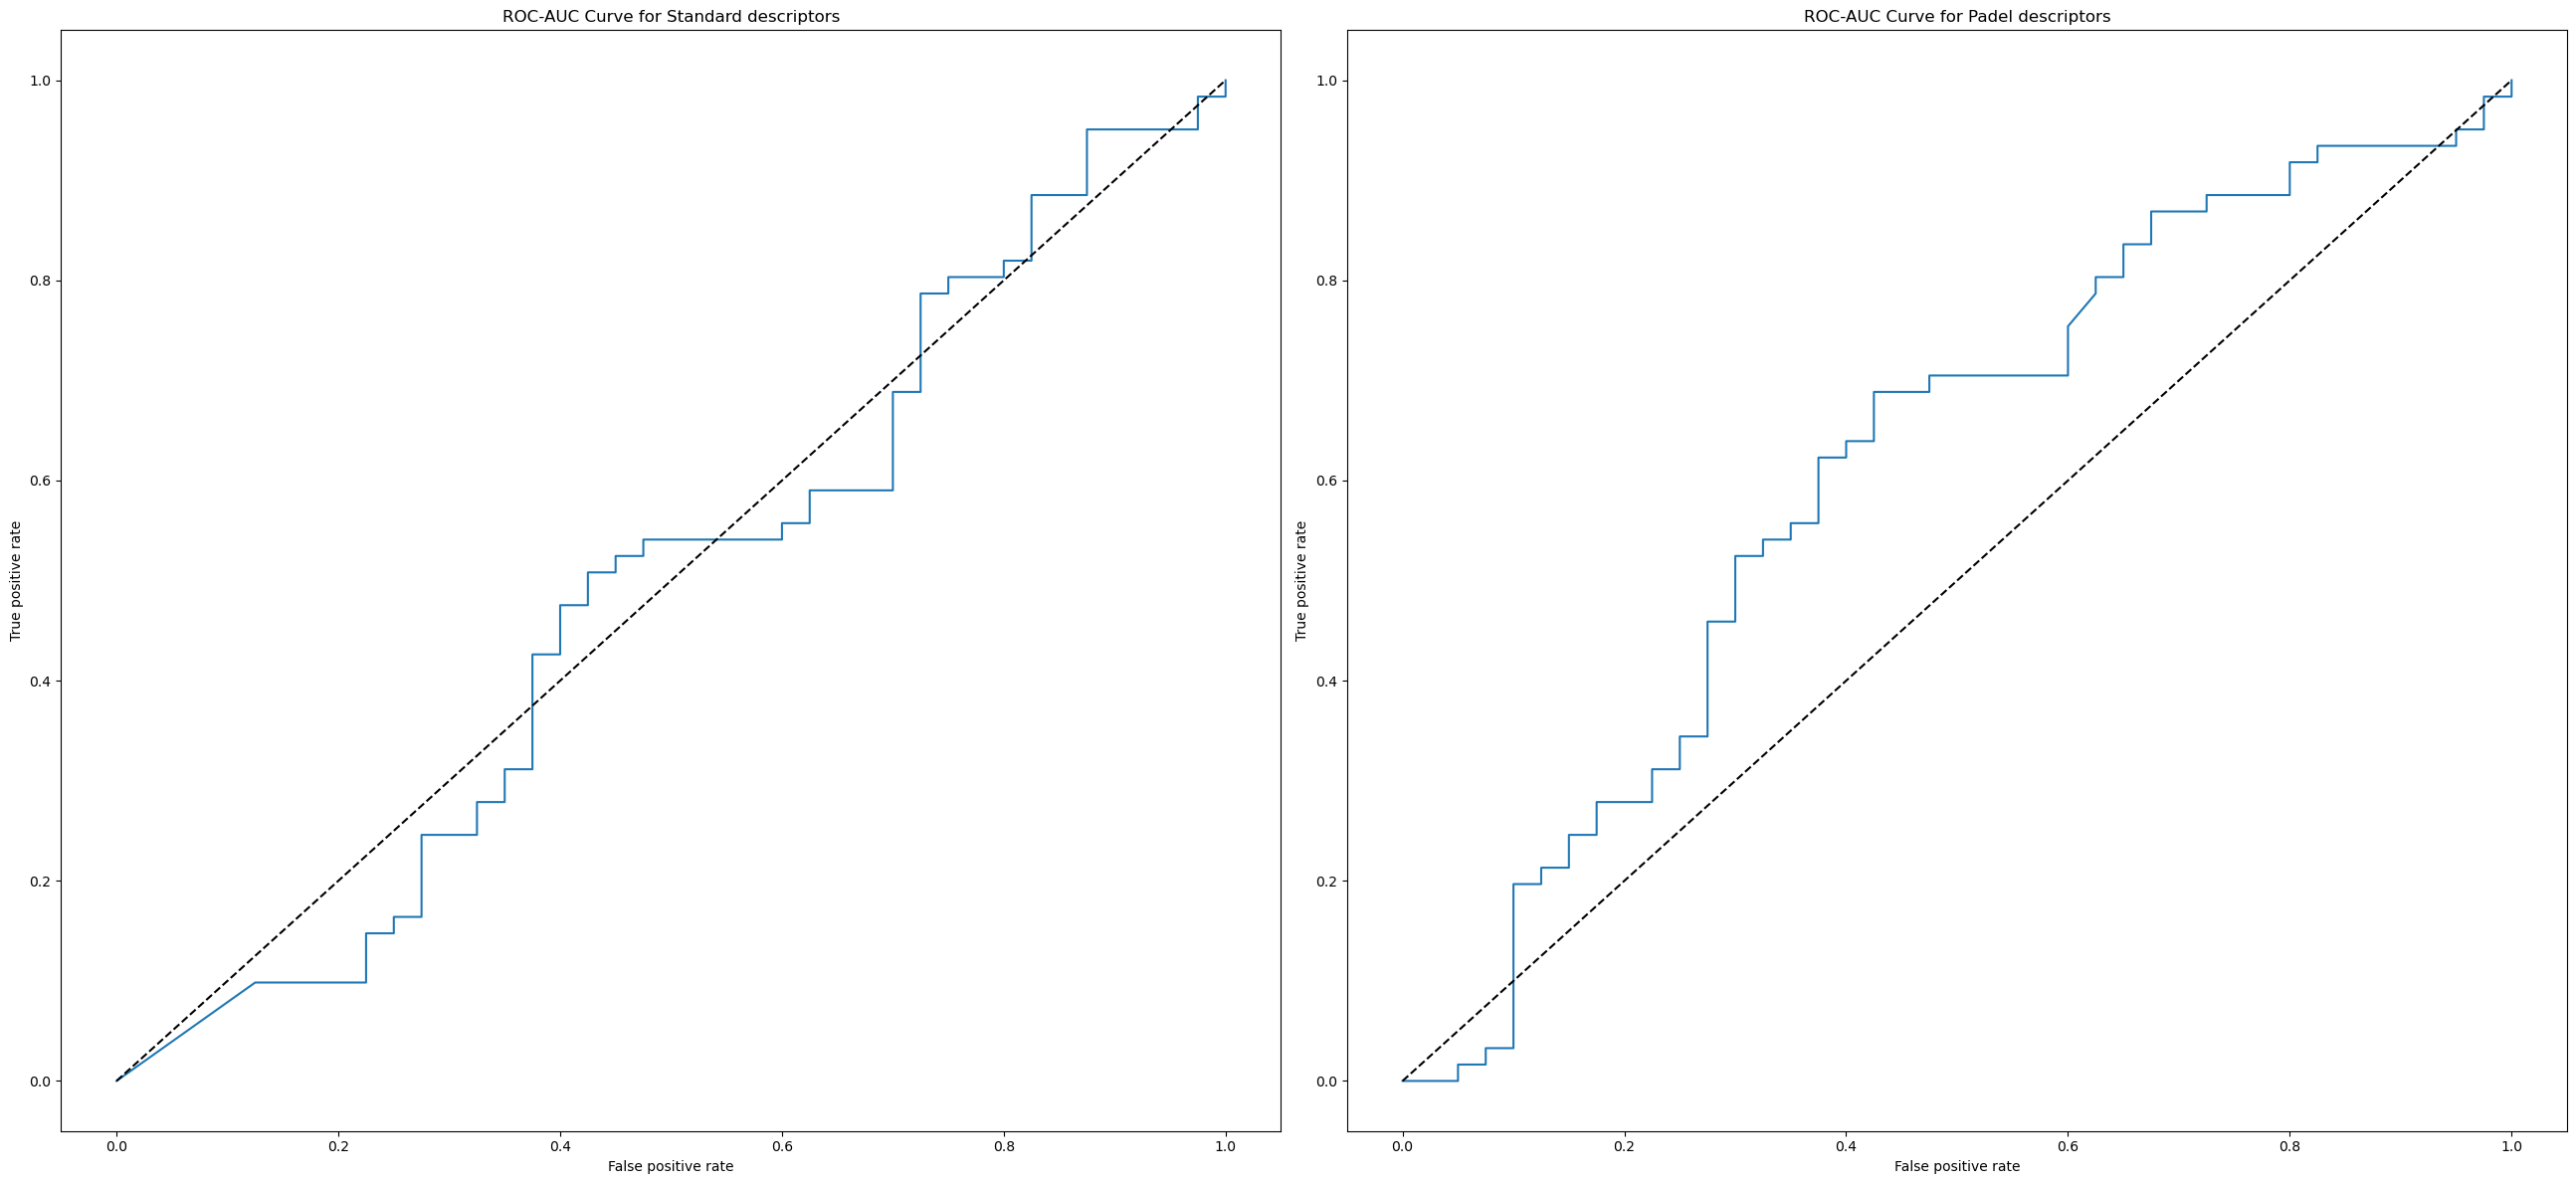

In [49]:
calculate_to_score(pipe, estimator_name='Logistic Regression', 
                   param_grid = param_grid)

100%|██████████| 50/50 [01:11<00:00,  1.43s/trial, best loss: -0.7147851176601178]
{'C': 0.03480623965680645, 'threshold': 0.08599254695690658}
Loss is 0.7147851176601178
Standard deviation is 0.142337097261691
100%|██████████| 50/50 [01:18<00:00,  1.58s/trial, best loss: -0.7188424314159608]
{'C': 0.016572530208911362, 'threshold': 0.10304882224168857}
Loss is 0.7188424314159608
Standard deviation is 0.15065702032030745


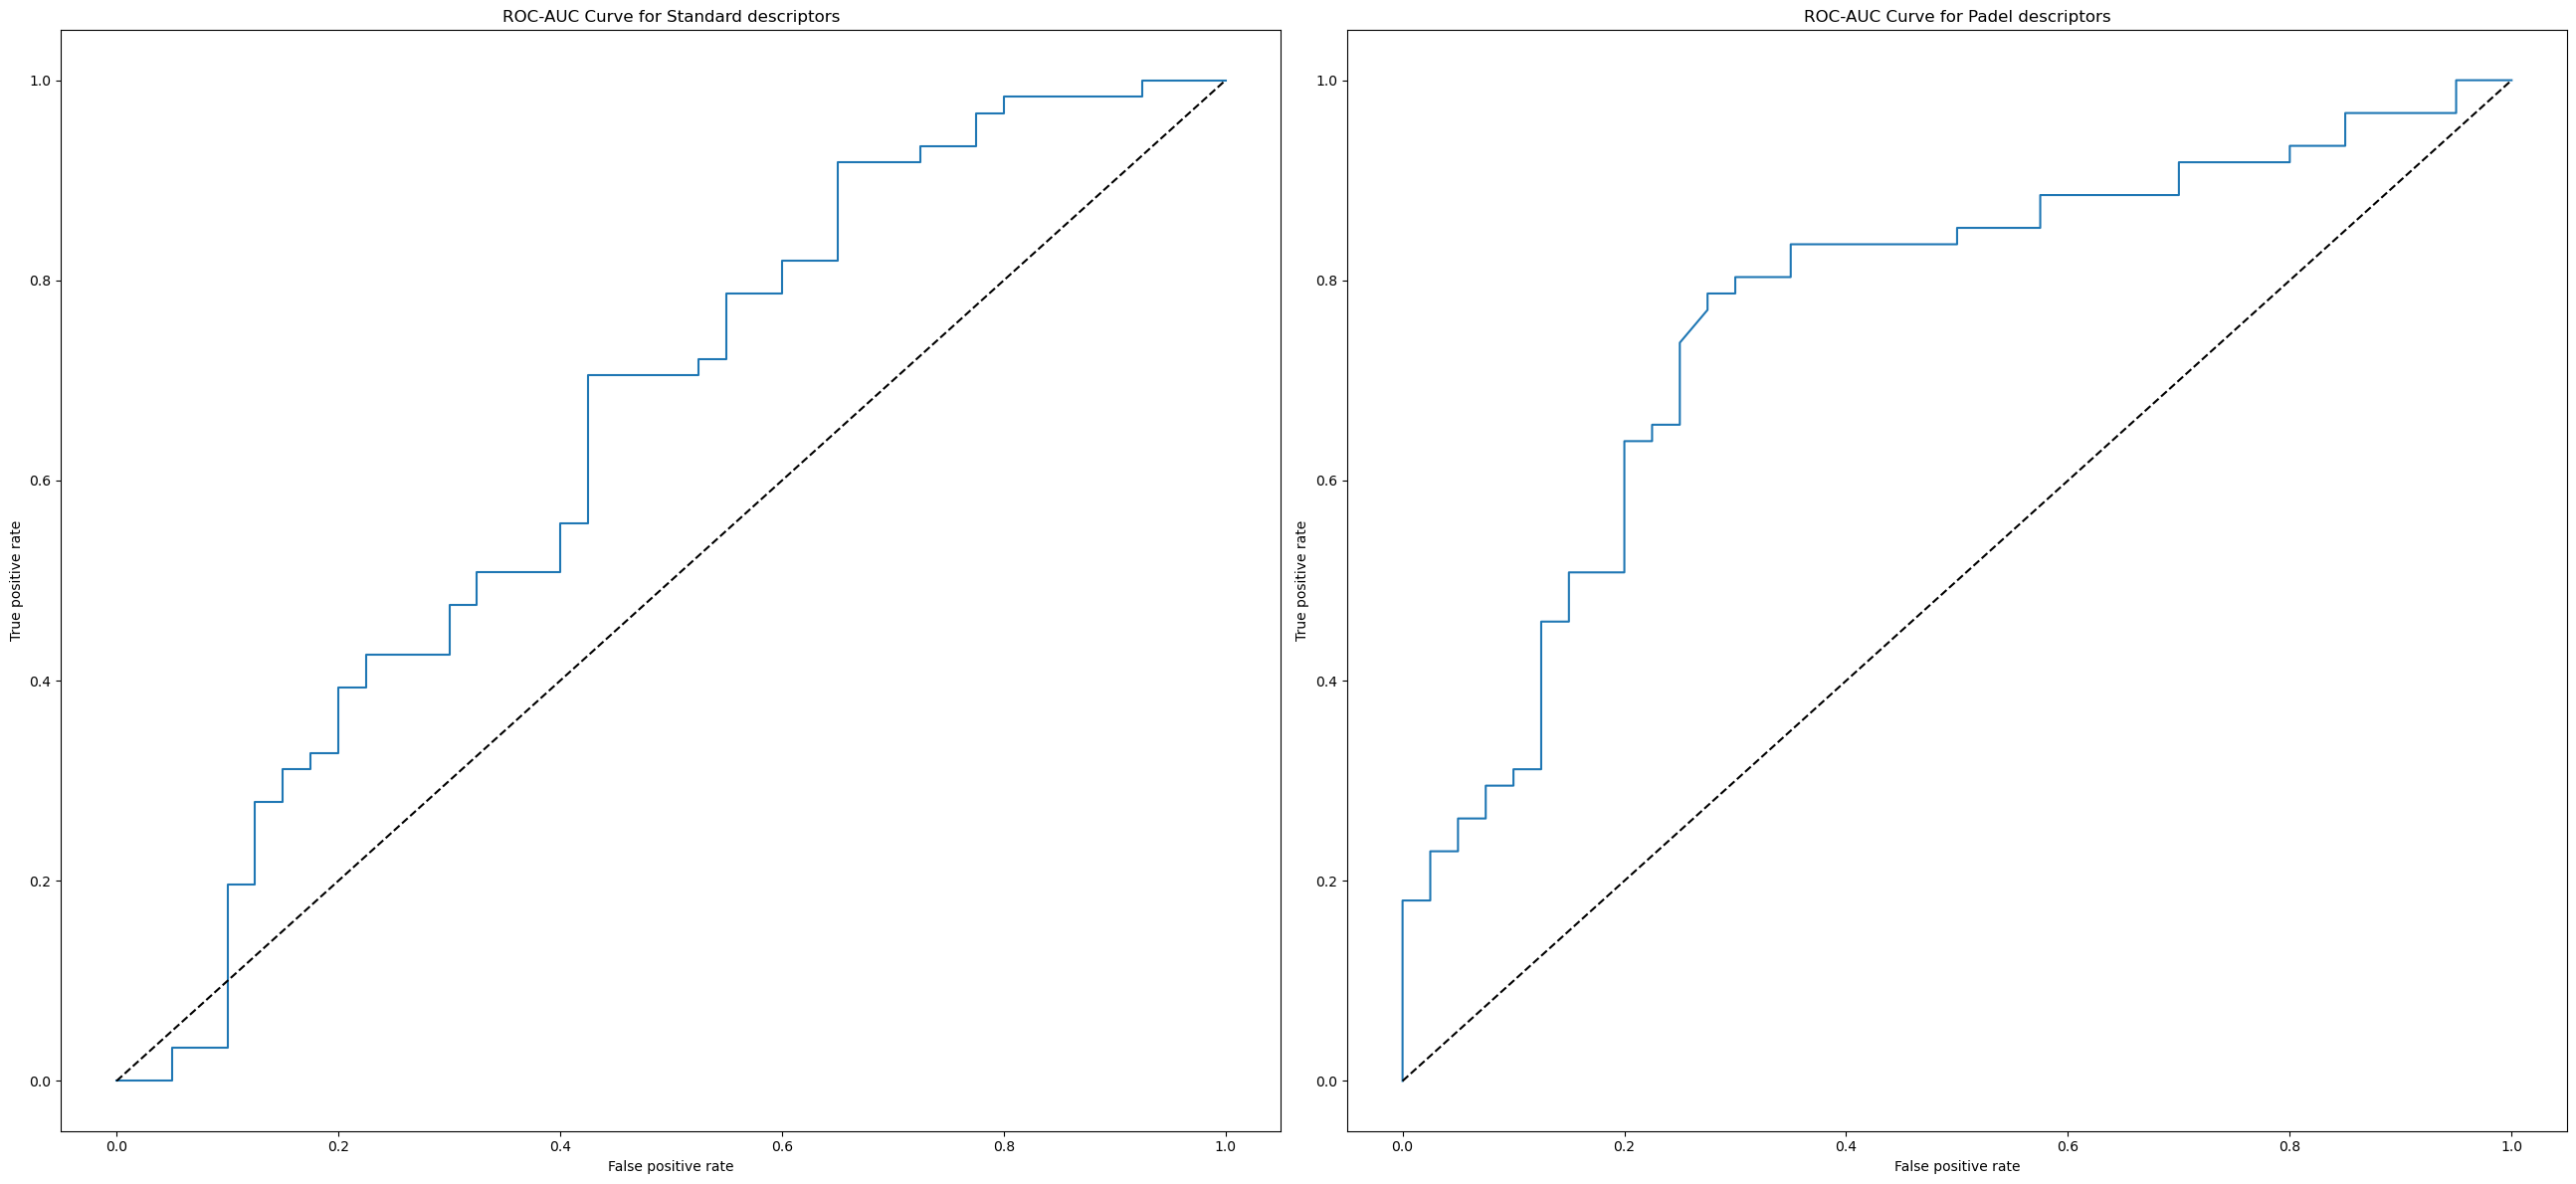

In [50]:
calculate_to_score(pipe, estimator_name='Logistic Regression', 
                   param_grid = param_grid,
                  descriptors_dict=descriptors_dict_pca, type = 'PCA')

Let's continue with other models. The first one will be
**Random Forest Classification**

In [63]:
pipe = Pipeline([('varsel', VarianceThreshold()),('randomforest', RandomForestClassifier(n_jobs = -1))])

In [65]:
space={'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
    'randomforest__max_depth':hp.randint('max_depth',1,50),  'randomforest__max_features':hp.choice('max_features', [None, 'sqrt', 'log2']),
       'randomforest__min_samples_split':hp.randint('min_samples_split', 2, 8),
       'randomforest__min_samples_leaf': hp.randint('min_samples_leaf', 1, 10),
      'randomforest__n_estimators':hp.randint('n_estimators',50, 500),
      'randomforest__criterion': hp.choice('criterion', ["gini", "entropy", "log_loss"])}

100%|██████████| 50/50 [24:30<00:00, 29.41s/trial, best loss: -0.7949338173737661]
{'criterion': 0, 'max_depth': 28, 'max_features': 0, 'min_samples_leaf': 7, 'min_samples_split': 5, 'n_estimators': 301, 'threshold': 0.15572186483540662}
Loss is 0.7949338173737661
Standard deviation is 0.09808708439014044
100%|██████████| 50/50 [26:37<00:00, 31.96s/trial, best loss: -0.7726196135019665]
{'criterion': 2, 'max_depth': 38, 'max_features': 0, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 102, 'threshold': 0.36827749485012257}
Loss is 0.7726196135019665
Standard deviation is 0.12802295140174877


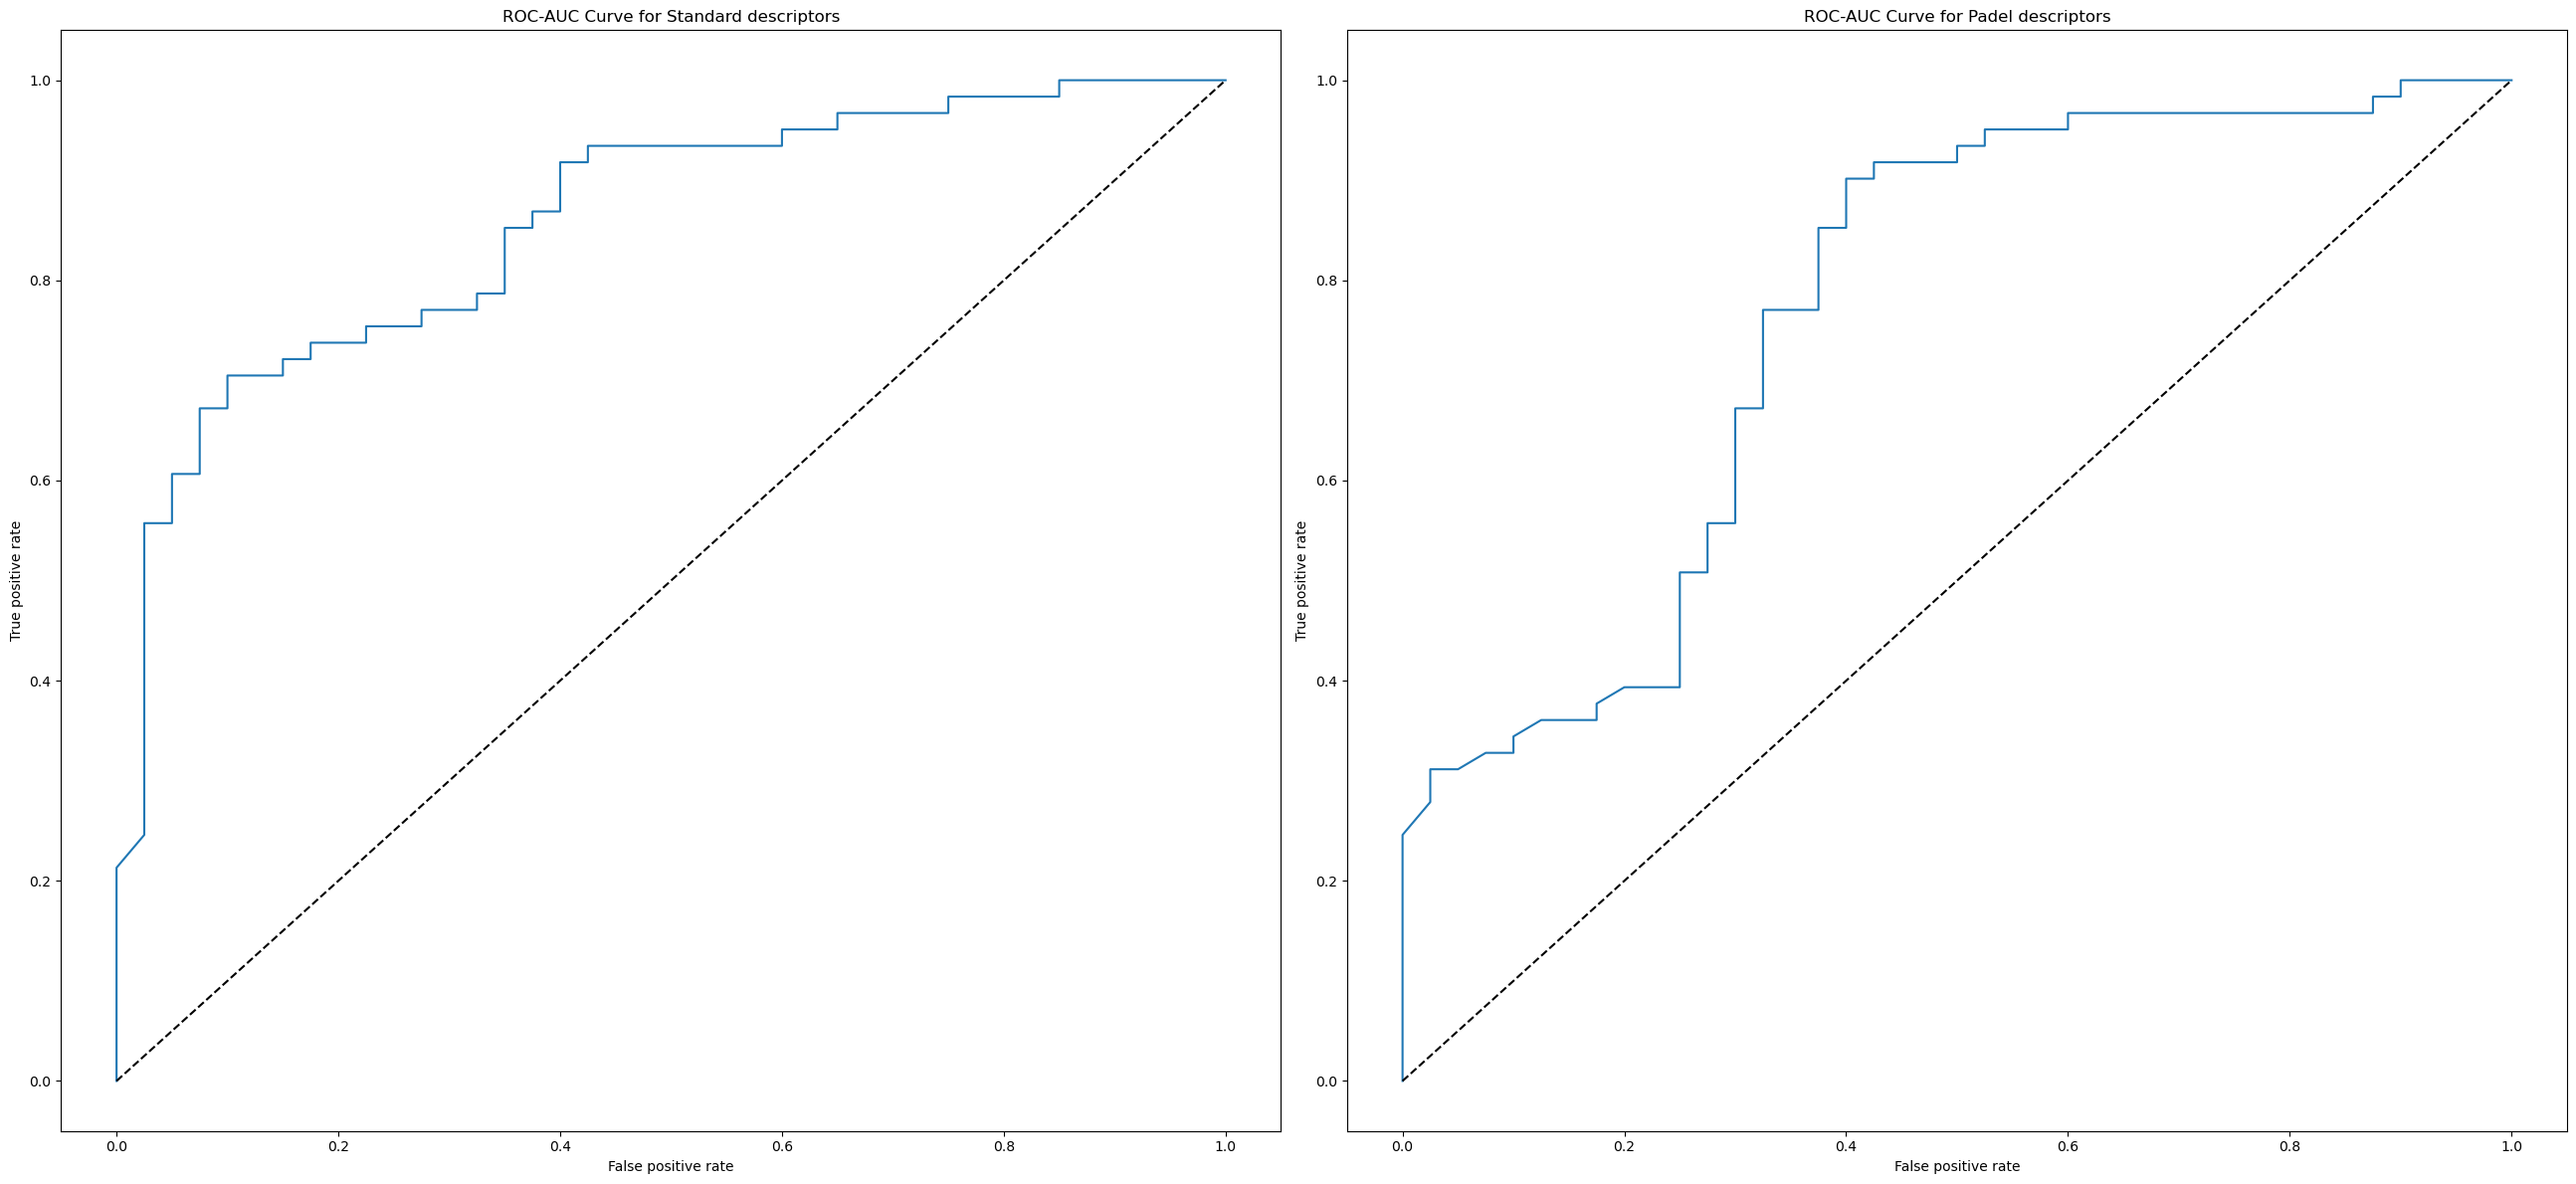

In [67]:
calculate_to_score(pipe, estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict,
                   target=target,type = 'Full')
               

100%|██████████| 50/50 [20:51<00:00, 25.03s/trial, best loss: -0.7938654607533325]
{'criterion': 0, 'max_depth': 21, 'max_features': 0, 'min_samples_leaf': 9, 'min_samples_split': 5, 'n_estimators': 147, 'threshold': 0.07918394439351789}
Loss is 0.7938654607533325
Standard deviation is 0.10490191179619429
100%|██████████| 50/50 [25:59<00:00, 31.18s/trial, best loss: -0.7692573167573167]
{'criterion': 0, 'max_depth': 38, 'max_features': 0, 'min_samples_leaf': 6, 'min_samples_split': 4, 'n_estimators': 431, 'threshold': 0.1367803041580803}
Loss is 0.7692573167573167
Standard deviation is 0.12190522965780318


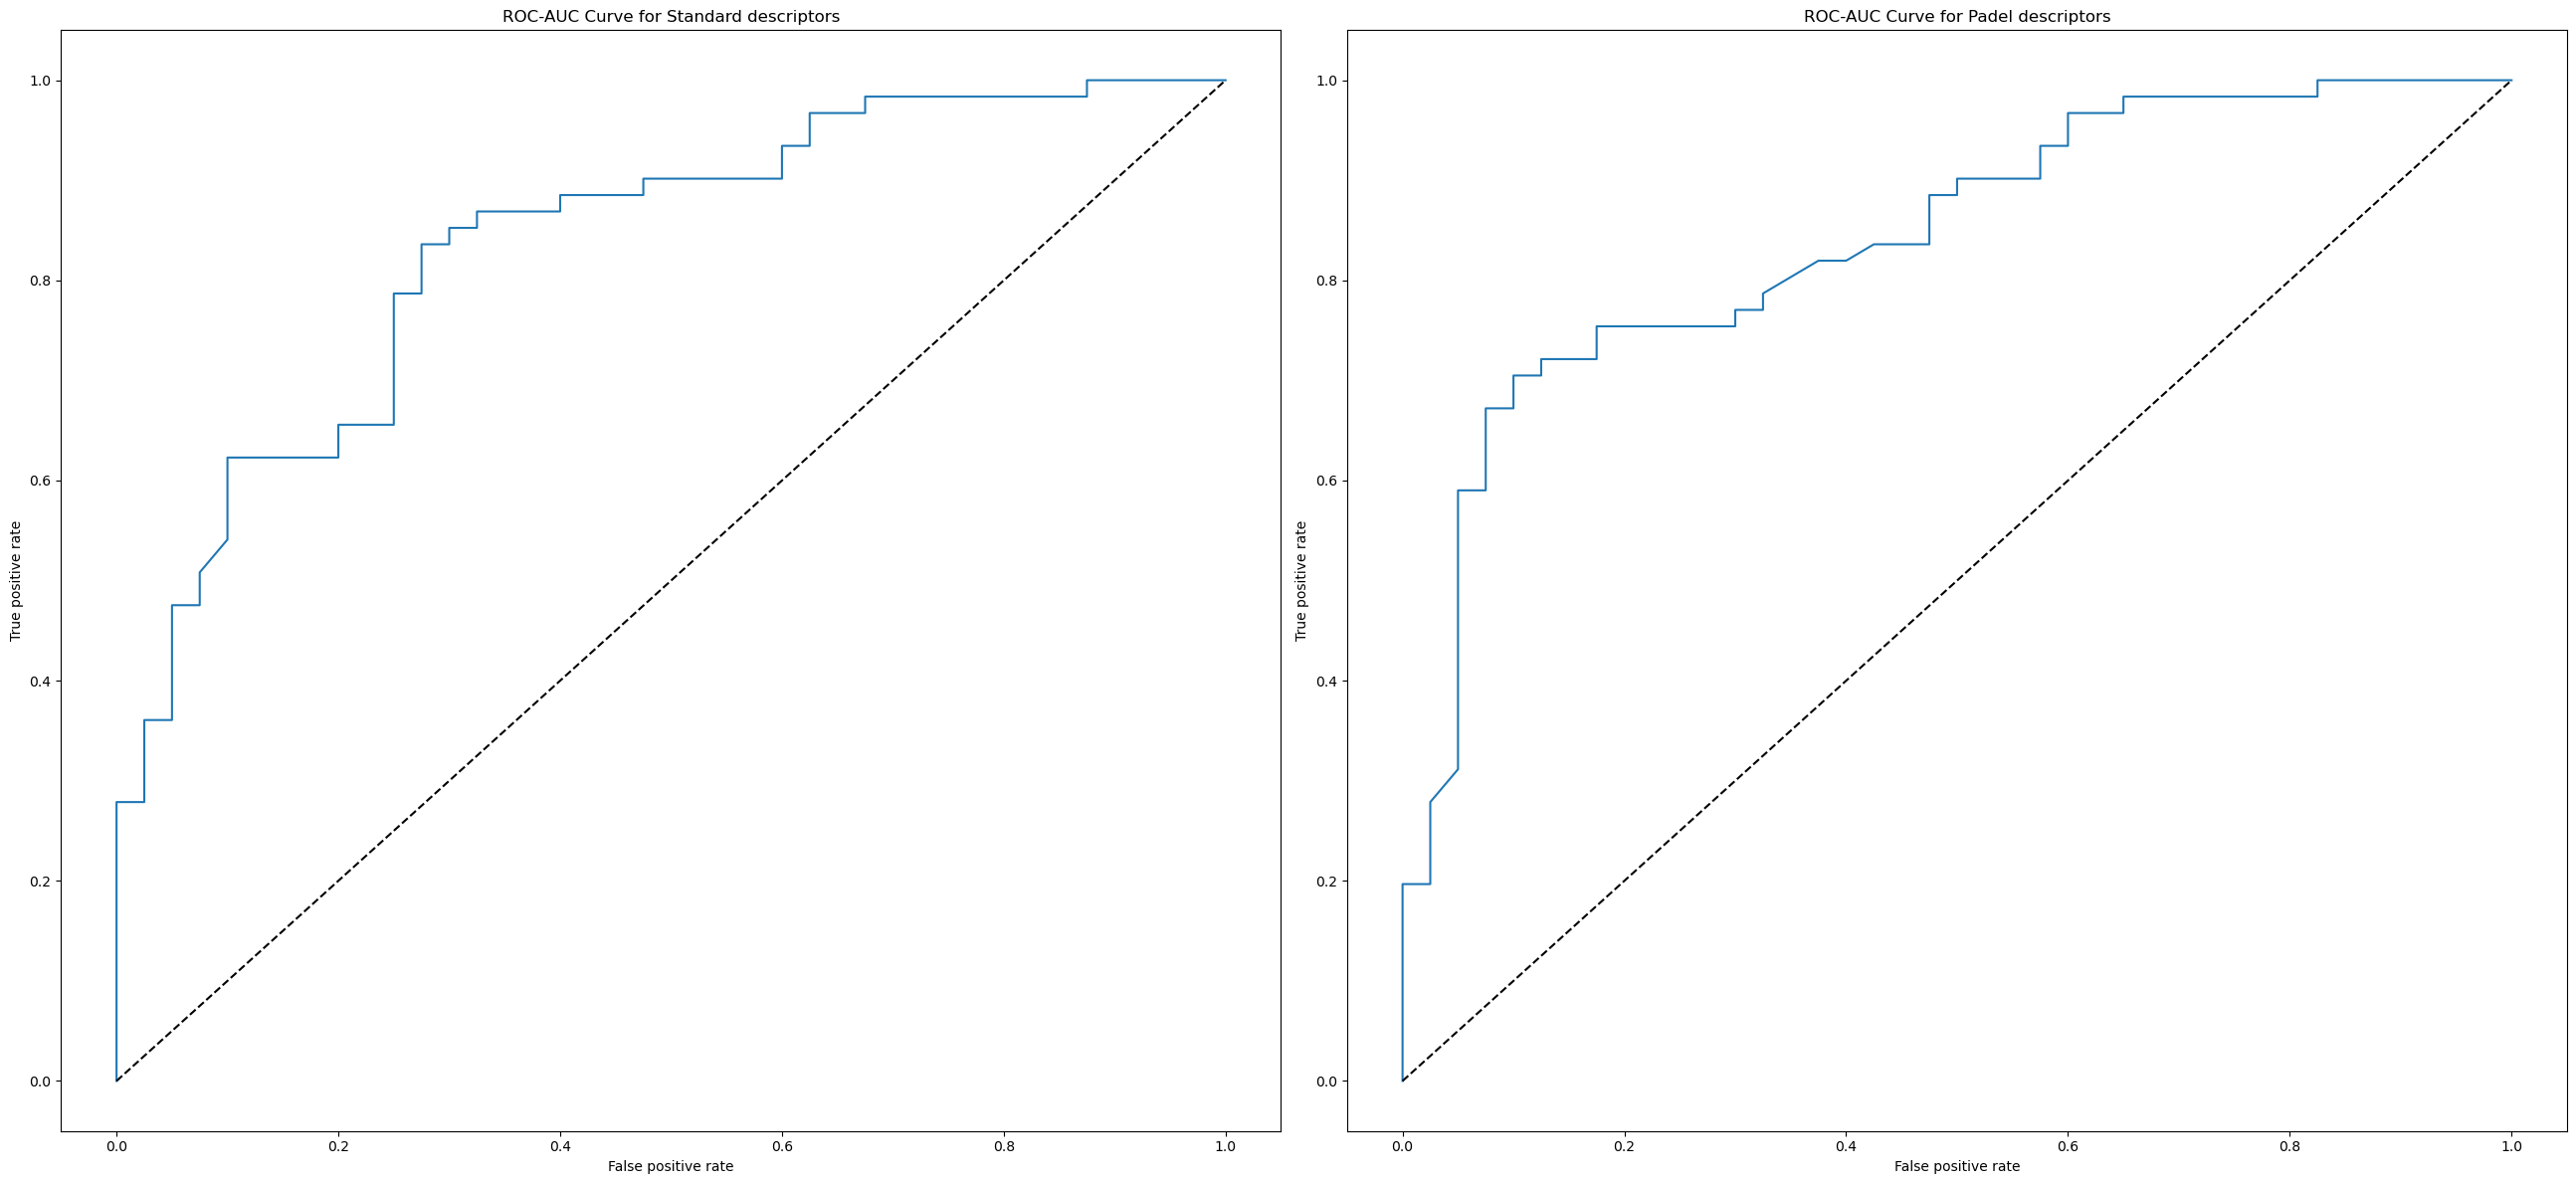

In [68]:
calculate_to_score(pipe, estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict_pca,
                   target=target,                   type = 'PCA')


**XGBoost**

In [69]:
pipe = Pipeline([('varsel', VarianceThreshold()),('xgbclassifier', XGBClassifier(n_jobs = -1))])

In [70]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
        'xgbclassifier__n_estimators':hp.randint('n_estimators', 1, 30),
         'xgbclassifier__learning_rate': hp.loguniform('learning_rate', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbclassifier__reg_alpha':hp.loguniform(label = 'reg_alpha', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbclassifier__max_depth':hp.randint('max_depth', 1, 100)}

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 78%|███████▊  | 39/50 [03:54<01:21,  7.41s/trial, best loss: -0.8039833575767947]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 84%|████████▍ | 42/50 [04:13<00:56,  7.07s/trial, best loss: -0.8039833575767947]

...

 66%|██████▌   | 33/50 [02:24<01:11,  4.22s/trial, best loss: -0.797555167221584]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 78%|███████▊  | 39/50 [02:48<00:37,  3.38s/trial, best loss: -0.797555167221584]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [03:32<00:00,  4.26s/trial, best loss: -0.797555167221584]
{'learning_rate': 0.44789438761445294, 'max_depth': 46, 'n_estimators': 7, 'reg_alpha': 3.984970787918585, 'threshold': 0.3131957393222562}
Loss is 0.797555167221584
Standard deviation is 0.09818418136918884


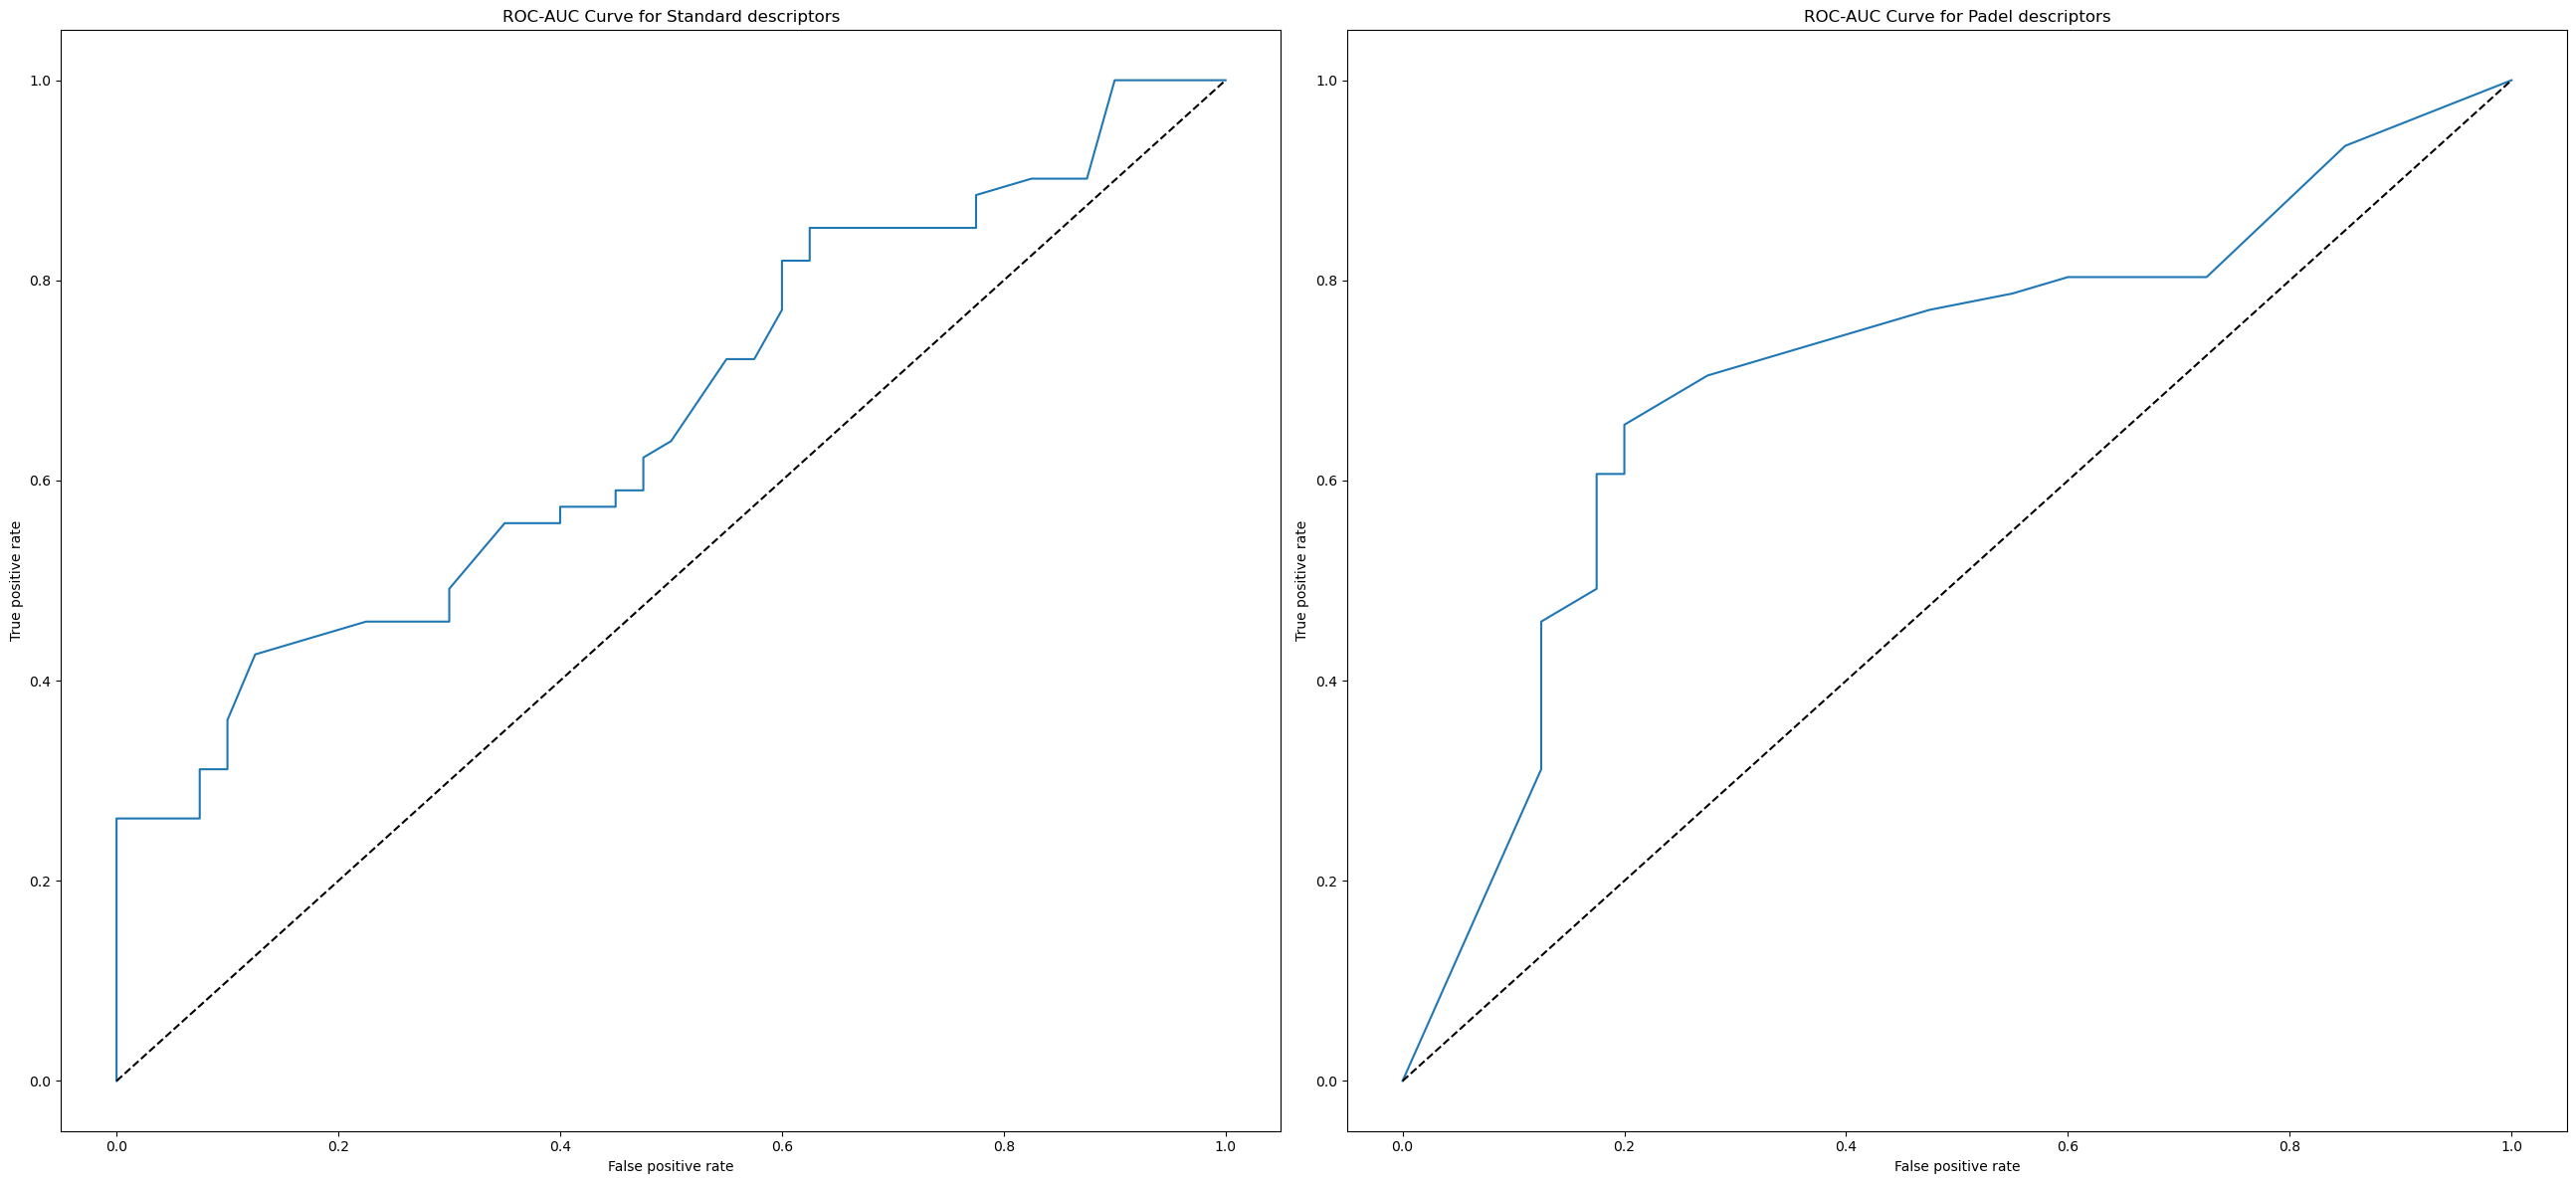

In [71]:
calculate_to_score(pipe, estimator_name='Gradient boosting', param_grid = space,
                   descriptors_dict=descriptors_dict,
                   target=target,
                   type = 'Full')

  8%|▊         | 4/50 [00:18<03:13,  4.21s/trial, best loss: -0.7741137775119398]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 10%|█         | 5/50 [00:21<02:49,  3.78s/trial, best loss: -0.7741137775119398]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 14%|█▍        | 7/50 [00:31<03:12,  4.47s/trial, best loss: -0.7741137775119398]

...

 74%|███████▍  | 37/50 [03:05<00:54,  4.20s/trial, best loss: -0.773949867336964]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 84%|████████▍ | 42/50 [03:23<00:26,  3.35s/trial, best loss: -0.773949867336964]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [04:01<00:00,  4.83s/trial, best loss: -0.773949867336964]
{'learning_rate': 0.8947270164557658, 'max_depth': 70, 'n_estimators': 7, 'reg_alpha': 2.295340617880065, 'threshold': 0.37259260977147335}
Loss is 0.773949867336964
Standard deviation is 0.1434112429951498


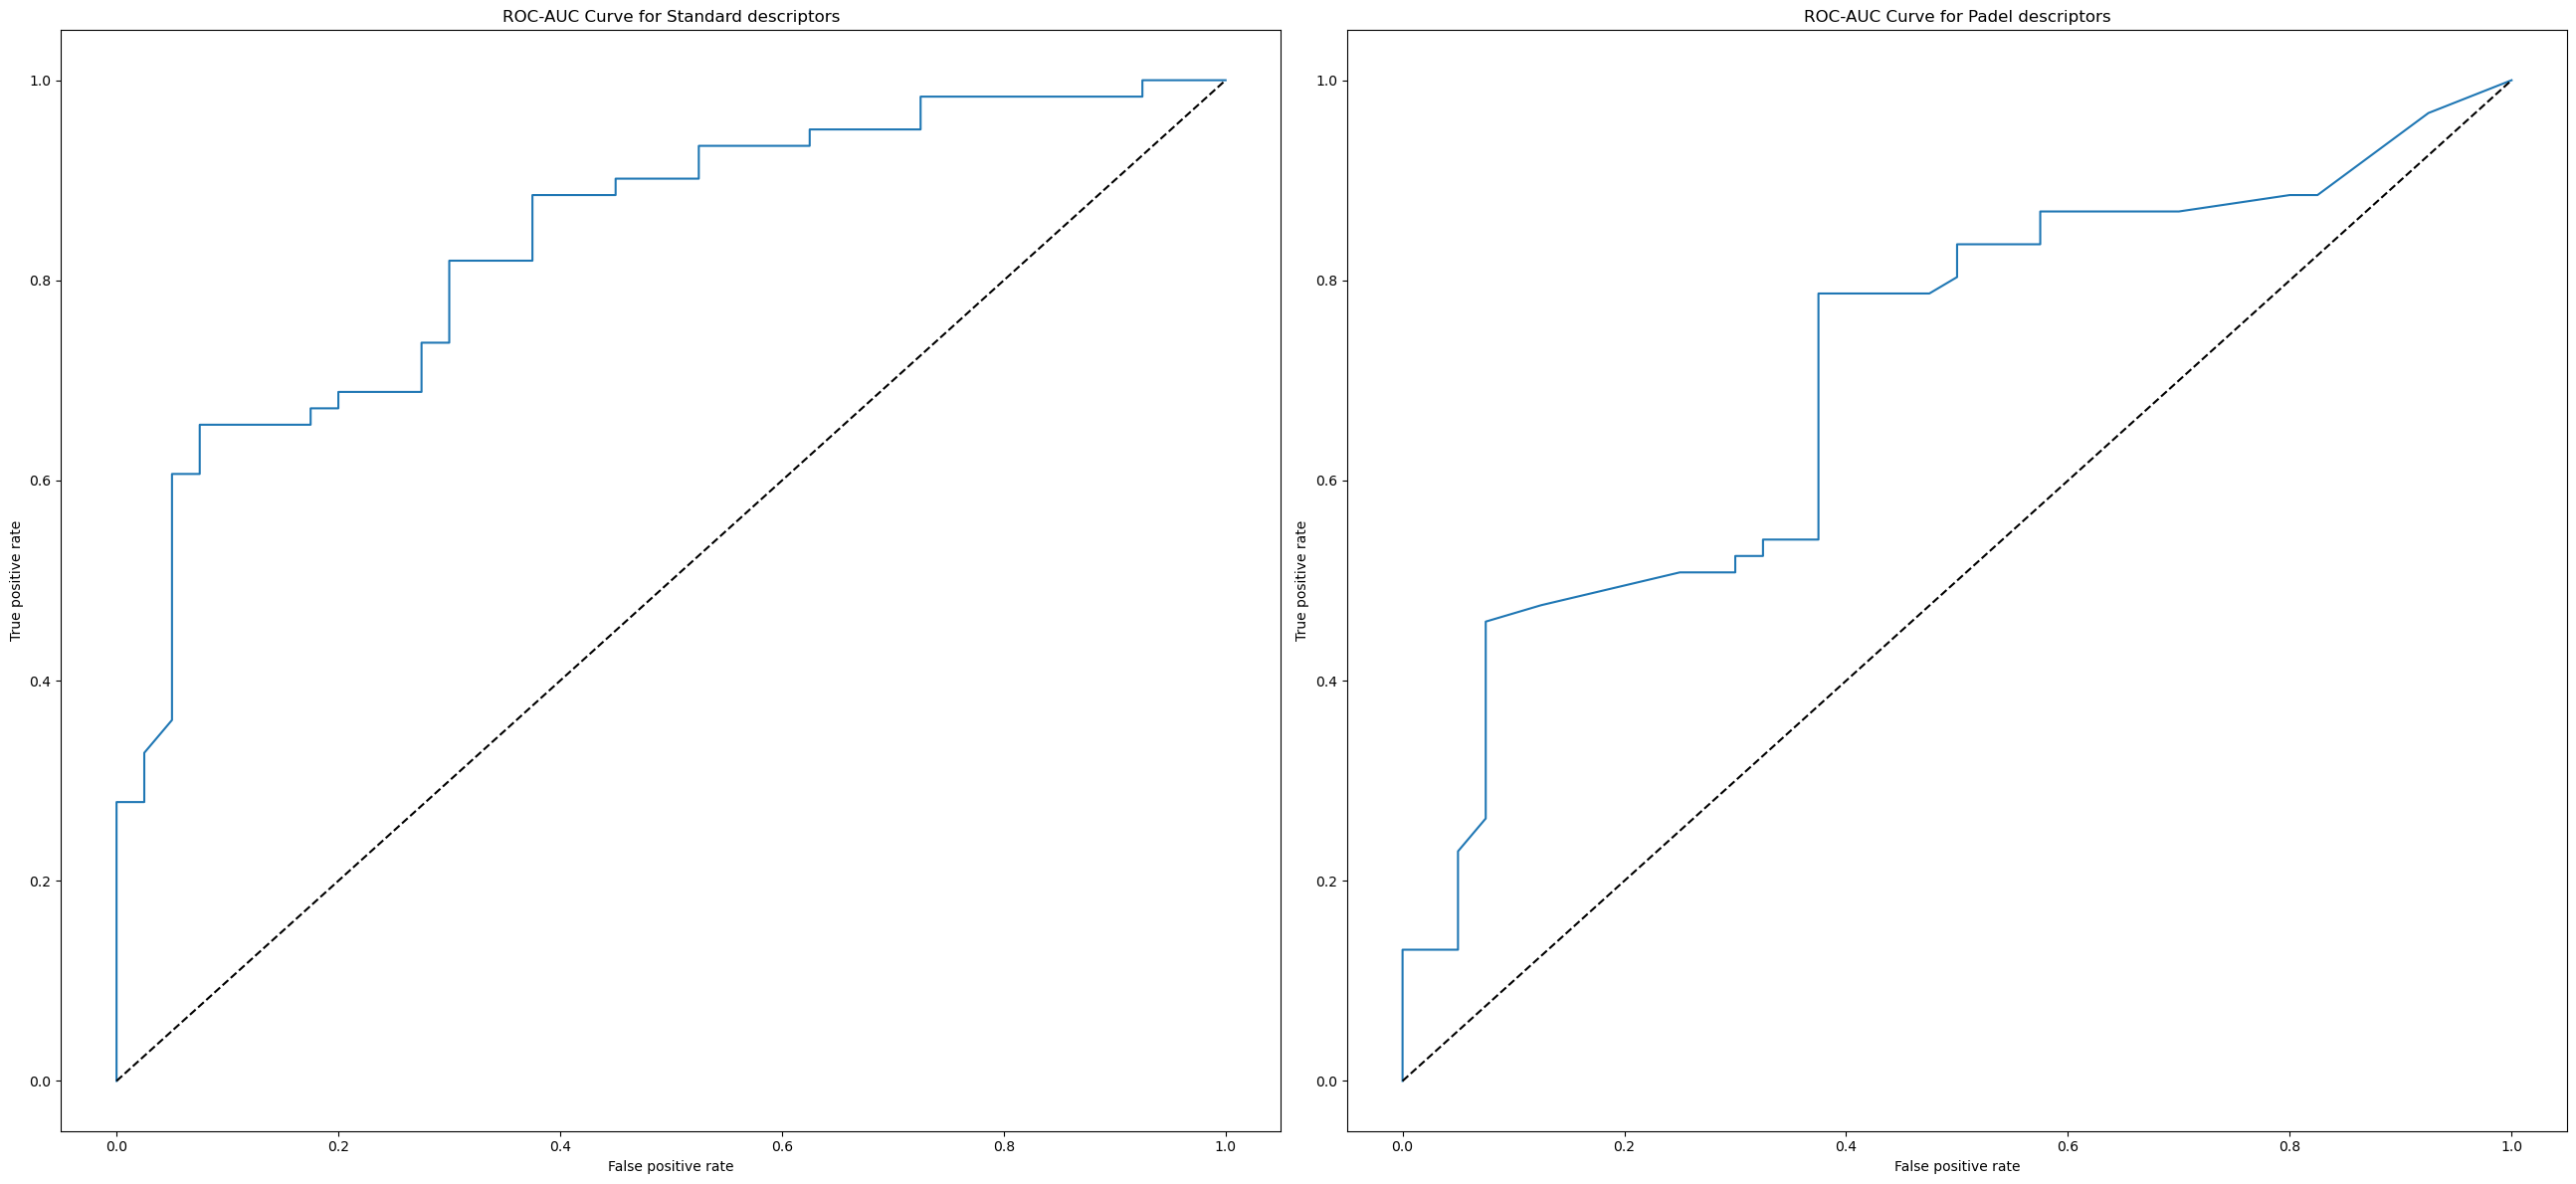

In [72]:
calculate_to_score(pipe, estimator_name='Gradient boosting', param_grid = space,
                   descriptors_dict=descriptors_dict_pca,
                   target=target,
                   type = 'PCA')

**SVM**

In [53]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('model_sel',SelectFromModel(LogisticRegression(max_iter=10000))),
                 ('svc', SVC(probability=True))])

In [55]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
         'model_sel__estimator__C':hp.loguniform(label = 'alpha', low = -1, high =2),
    'svc__C':hp.loguniform('C', -3*np.log(10), 2*np.log(10)),
         'svc__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svc__degree':hp.choice('degree', [2,3]),
         'svc__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svc__coef0':hp.loguniform('coef0', -3*np.log(10), 0*np.log(10))}

 20%|██        | 10/50 [00:27<01:53,  2.84s/trial, best loss: -0.6708080608818399]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T

 22%|██▏       | 11/50 [00:30<01:42,  2.63s/trial, best loss: -0.6708080608818399]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 44%|████▍     | 22/50 [00:58<01:13,  2.62s/trial, best loss: -0.722154403567447] 

...

 86%|████████▌ | 43/50 [01:51<00:19,  2.82s/trial, best loss: -0.7484159261790841]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 88%|████████▊ | 44/50 [01:54<00:16,  2.73s/trial, best loss: -0.7484159261790841]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [02:09<00:00,  2.59s/trial, best loss: -0.7484159261790841]
{'C': 0.711939976701923, 'alpha': 2.3206551396948463, 'coef0': 0.24090147355659688, 'degree': 1, 'gamma': 0, 'kernel': 1, 'threshold': 0.20772778990015134}
Loss is 0.7484159261790841
Standard deviation is 0.13487674949486564
100%|██████████| 50/50 [03:02<00:00,  3.64s/trial, best loss: -0.6901499773716095]
{'C': 1.5824632068318207, 'alpha': 0.39989688154197095, 'coef0': 0.001151363431411733, 'degree': 1, 'gamma': 1, 'kernel': 1, 'threshold': 0.09116460537403626}
Loss is 0.6901499773716095
Standard deviation is 0.14287561889925376


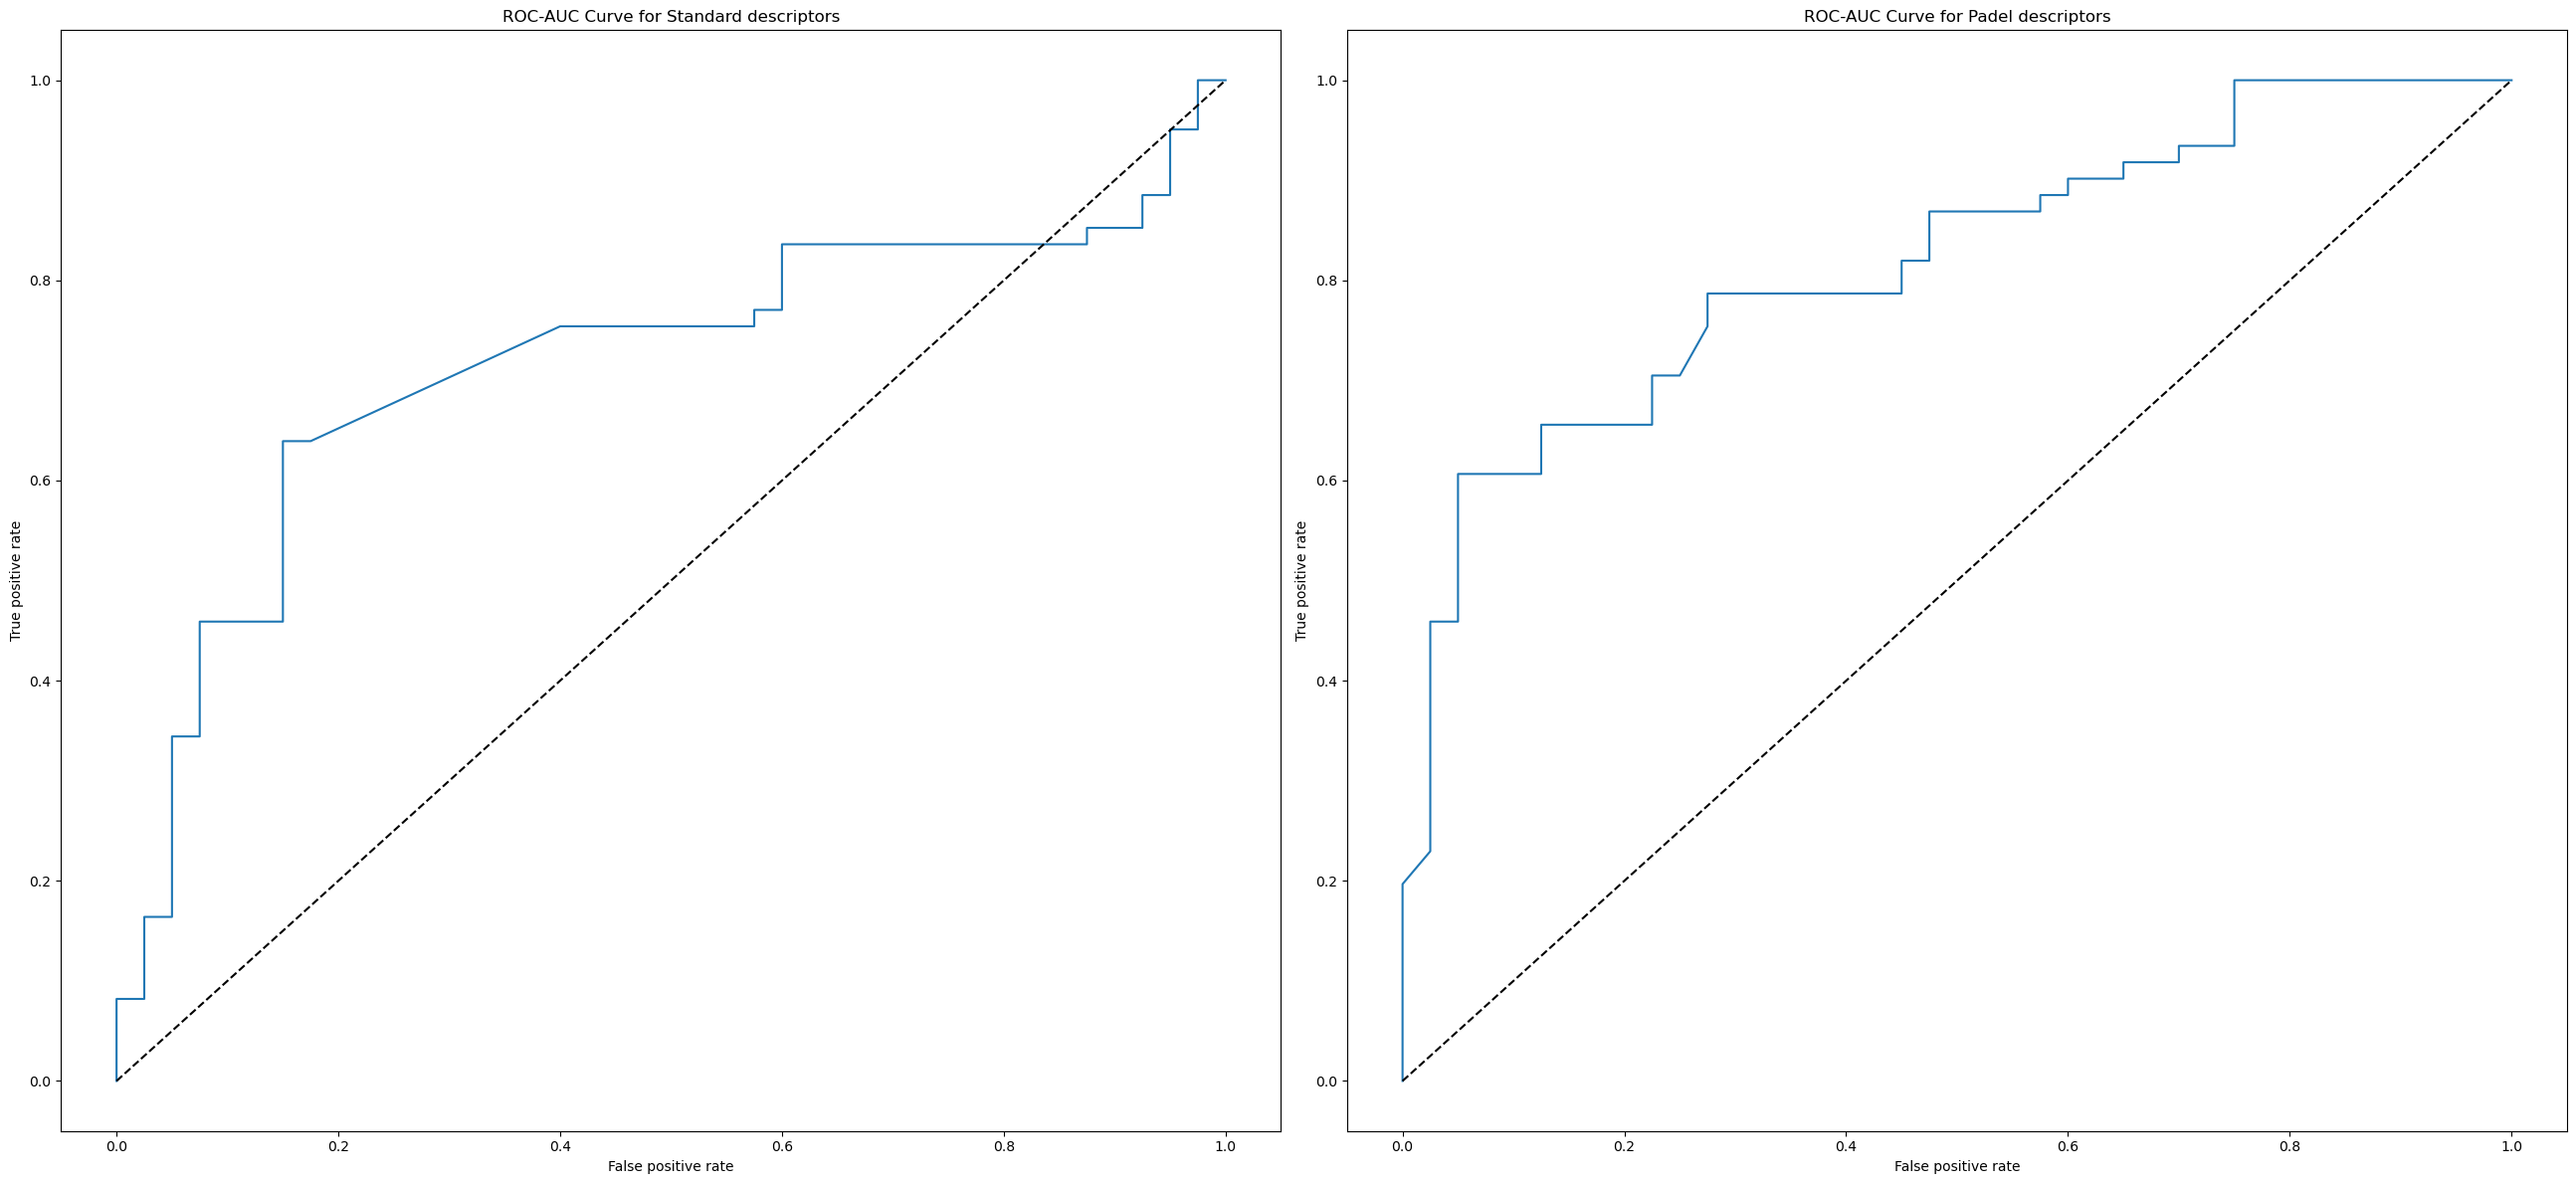

In [57]:
calculate_to_score(pipe, estimator_name = 'SVC', param_grid = space, descriptors_dict=descriptors_dict, target = target, type = 'Full')
                                                                


 36%|███▌      | 18/50 [00:48<01:33,  2.92s/trial, best loss: -0.7218237628384687]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 42%|████▏     | 21/50 [00:55<01:10,  2.42s/trial, best loss: -0.7218237628384687]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 58%|█████▊    | 29/50 [01:22<01:03,  3.03s/trial, best loss: -0.7394205794205794]

...

 78%|███████▊  | 39/50 [01:44<00:23,  2.16s/trial, best loss: -0.7475183150183151]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T

 80%|████████  | 40/50 [01:46<00:22,  2.24s/trial, best loss: -0.7475183150183151]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [02:09<00:00,  2.59s/trial, best loss: -0.7475183150183151]
{'C': 0.43036202672328194, 'alpha': 0.8052360916386183, 'coef0': 0.01171542091837767, 'degree': 1, 'gamma': 0, 'kernel': 1, 'threshold': 0.11562656640285554}
Loss is 0.7475183150183151
Standard deviation is 0.11671476925379447
100%|██████████| 50/50 [03:06<00:00,  3.72s/trial, best loss: -0.6908522735032647]
{'C': 0.9974986402986518, 'alpha': 3.3120170219596012, 'coef0': 0.004462488845595834, 'degree': 0, 'gamma': 1, 'kernel': 0, 'threshold': 0.1275620936402171}
Loss is 0.6908522735032647
Standard deviation is 0.11442583818202101


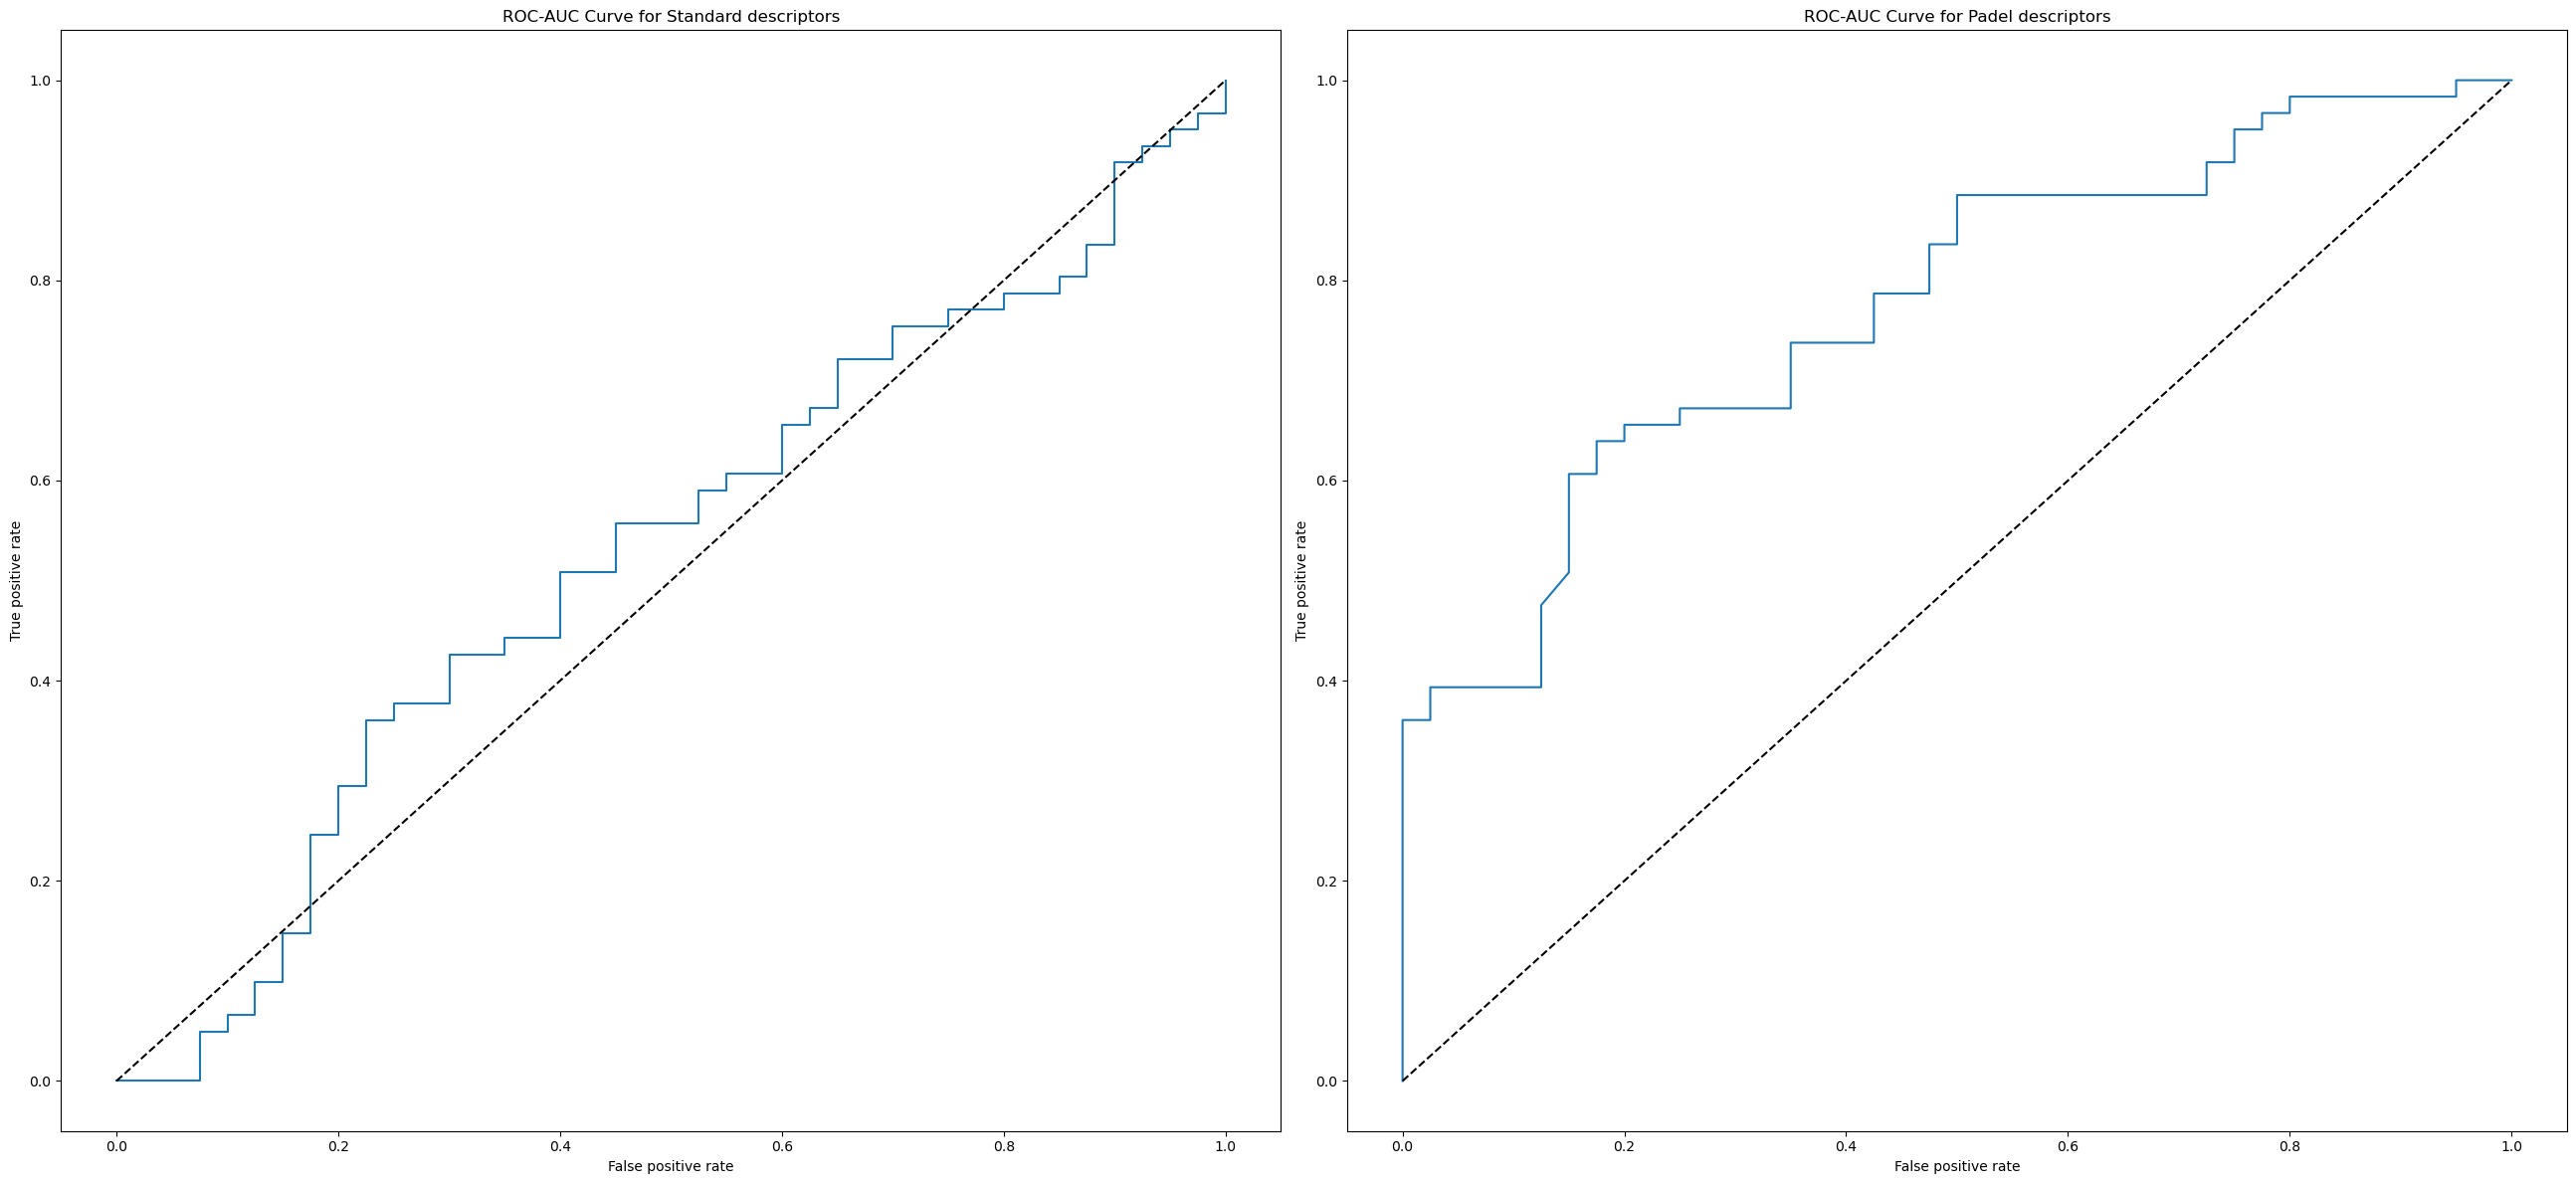

In [58]:
calculate_to_score(pipe, estimator_name = 'SVC', param_grid = space, descriptors_dict=descriptors_dict_pca, target = target, type = 'PCA')


**KNearestneighbors**

In [73]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('model_sel',SelectFromModel(LogisticRegression(max_iter=10000))),
                 ('kneighborsclassifier', KNeighborsClassifier())])

In [74]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
         'model_sel__estimator__C':hp.loguniform(label = 'alpha', low = -1, high =2),
    'kneighborsclassifier__n_neighbors':hp.randint('n_neighbors',1, 10),
         'kneighborsclassifier__weights':hp.choice('weights', ['uniform', 'distance']),
         'kneighborsclassifier__metric':hp.choice('metric', ['minkowski', 'chebyshev', 'cosine', 'euclidean'])}


100%|██████████| 50/50 [01:32<00:00,  1.84s/trial, best loss: -0.7186414711231174]
{'alpha': 5.259175117109072, 'metric': 3, 'n_neighbors': 6, 'threshold': 0.18463795508249434, 'weights': 0}
Loss is 0.7186414711231174
Standard deviation is 0.1003234376913675
100%|██████████| 50/50 [01:57<00:00,  2.36s/trial, best loss: -0.7327315795883571]
{'alpha': 0.6041150407856417, 'metric': 2, 'n_neighbors': 4, 'threshold': 0.017697483737325295, 'weights': 0}
Loss is 0.7327315795883571
Standard deviation is 0.14686255234798623


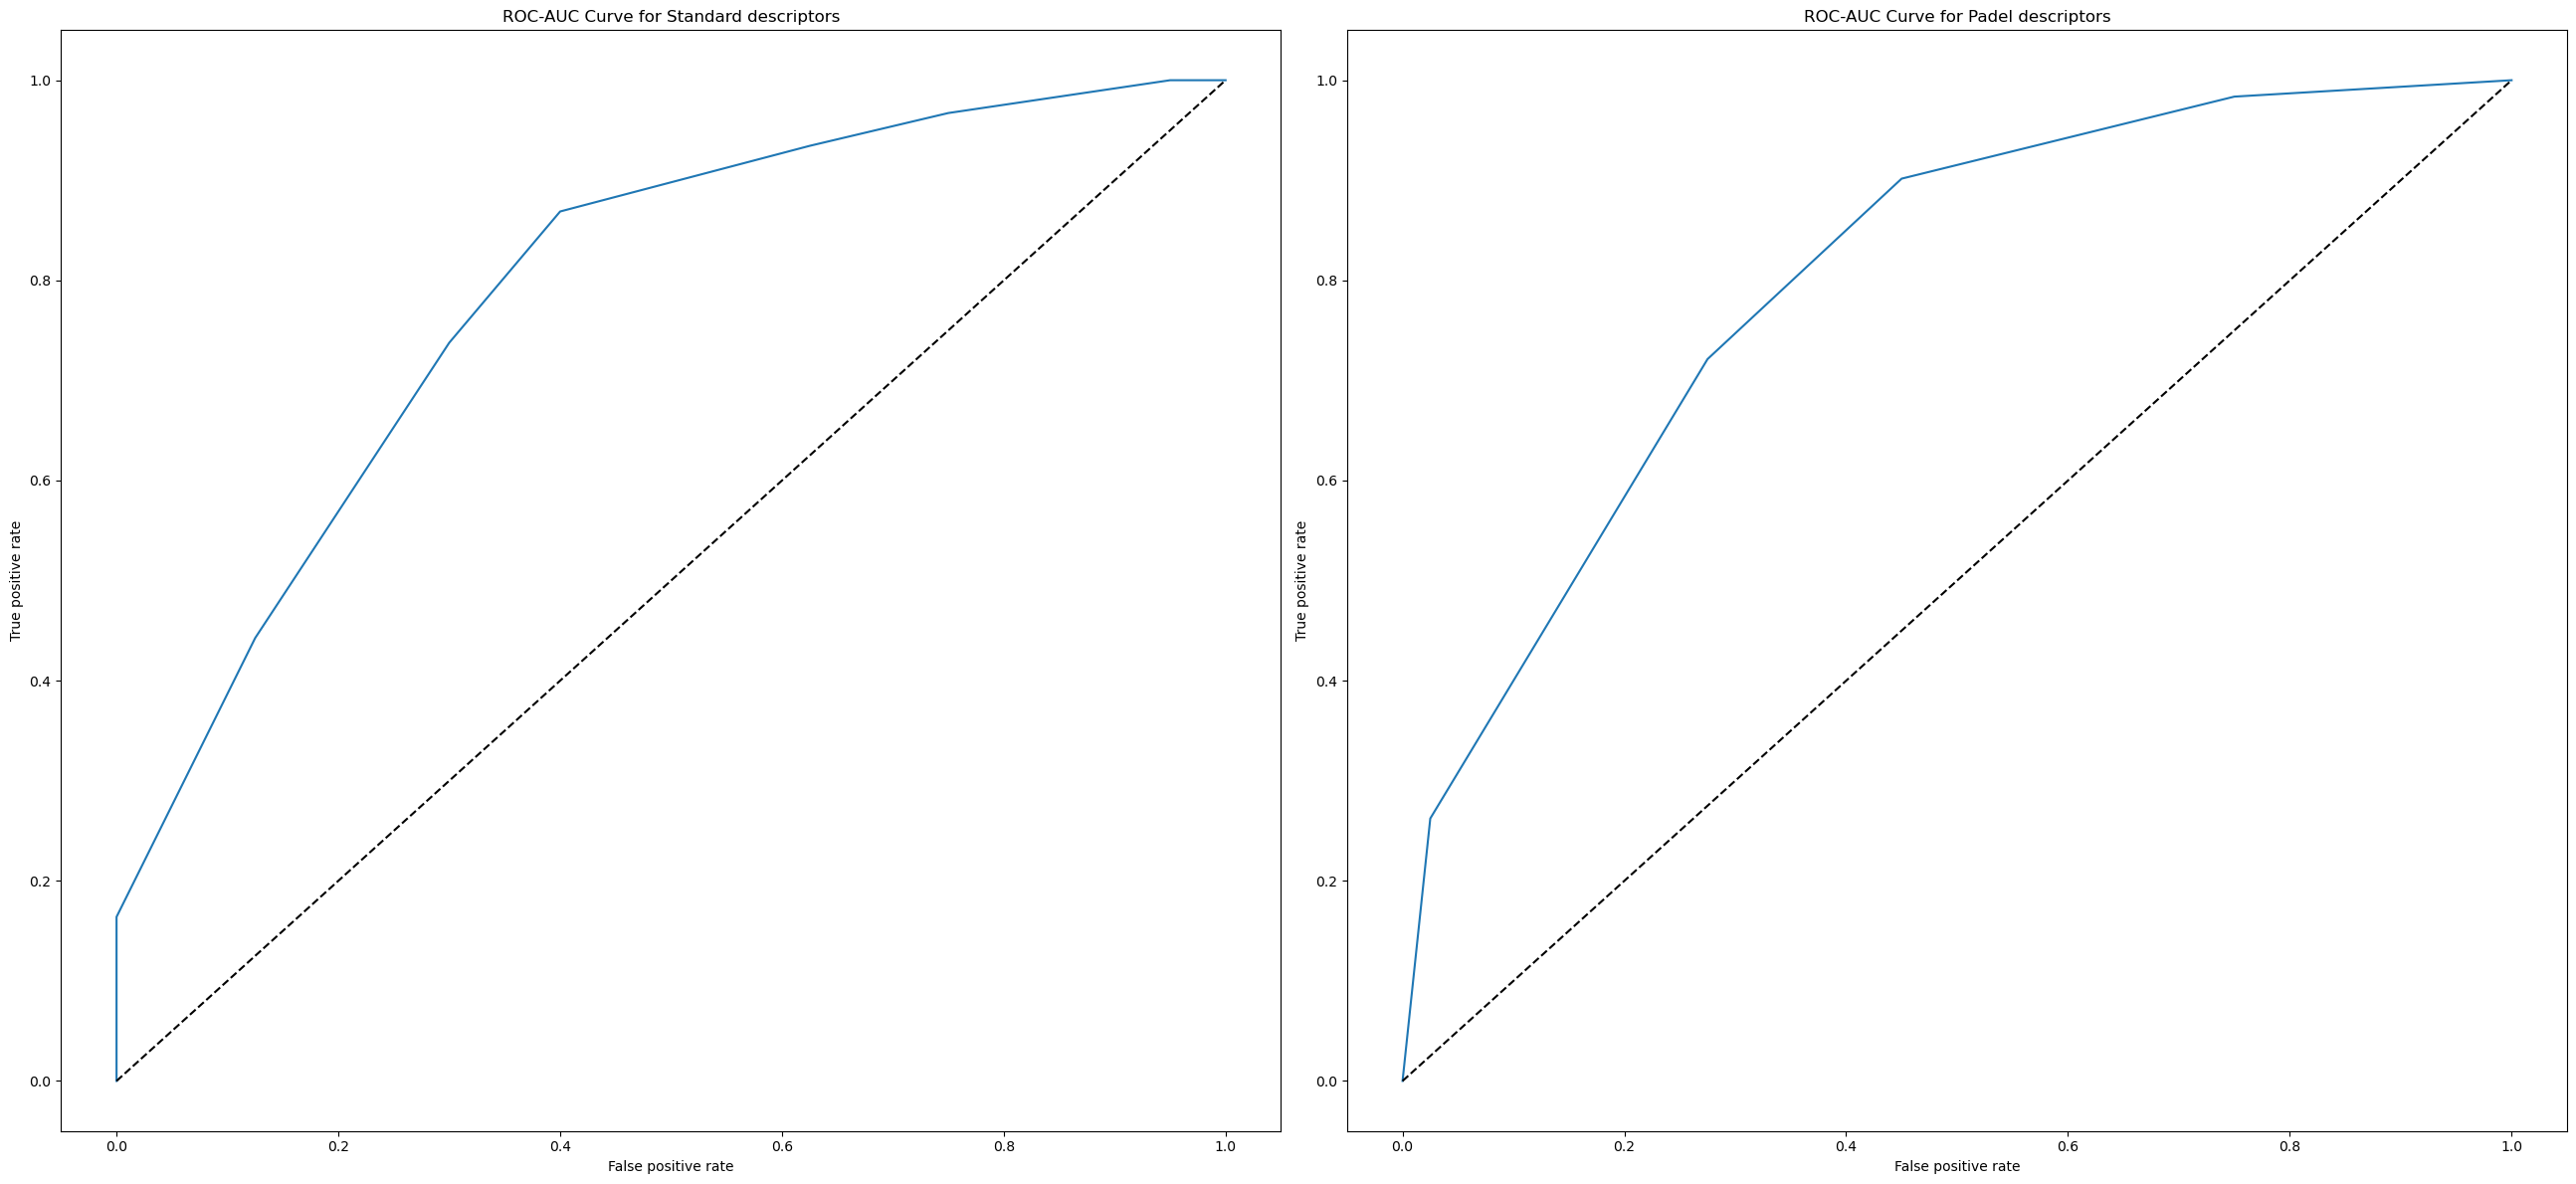

In [75]:
calculate_to_score(pipe, estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict, target=target, type = 'Full')

100%|██████████| 50/50 [01:31<00:00,  1.83s/trial, best loss: -0.7333139083139083]
{'alpha': 2.9593876353410797, 'metric': 0, 'n_neighbors': 2, 'threshold': 0.2490531973098046, 'weights': 0}
Loss is 0.7333139083139083
Standard deviation is 0.14284579877432405
 14%|█▍        | 7/50 [00:17<01:54,  2.66s/trial, best loss: -0.6466732014650862]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [02:11<00:00,  2.63s/trial, best loss: -0.7247923884947479]
{'alpha': 1.0166661968455748, 'metric': 2, 'n_neighbors': 2, 'threshold': 0.038734885470797675, 'weights': 0}
Loss is 0.7247923884947479
Standard deviation is 0.15335545839499437


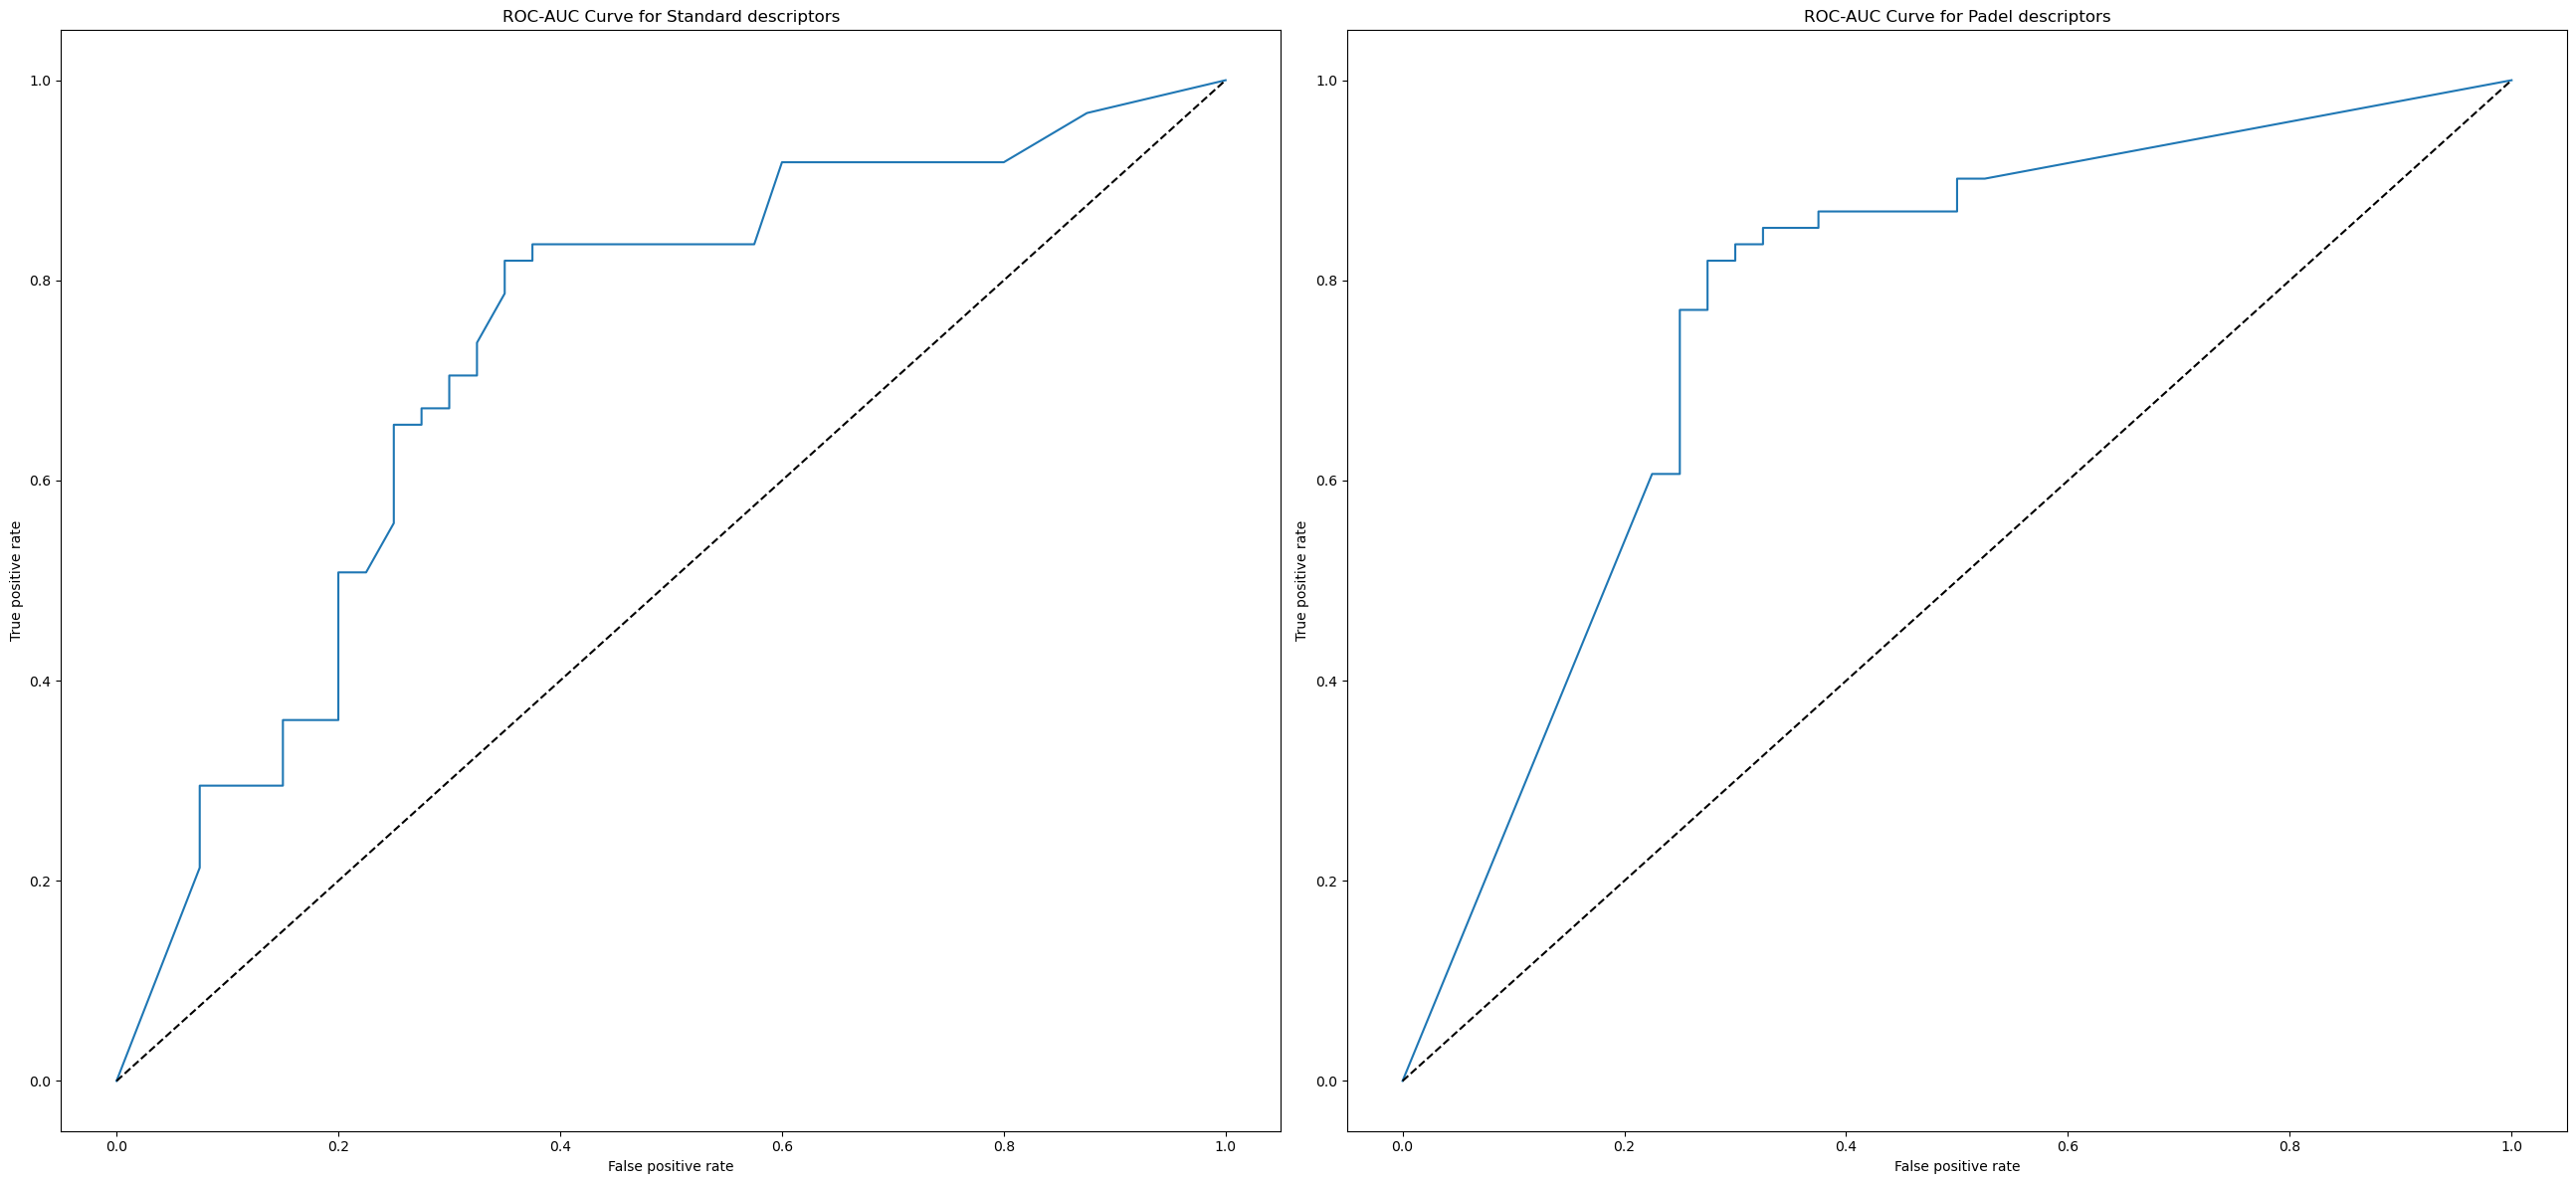

In [76]:
calculate_to_score(pipe, estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict_pca, target=target, type = 'PCA')

Let's save results into pickle file and show the final scores model in readable format

In [77]:
pd.DataFrame(scores)

,Descriptors,Full or PCA,Presicion_CV,Stddev_CV,Accuracy,F1 - score,ROC-AUC Score,Estimator,Recall score,Precision score
0,Standard,Full,0.719971,0.150266,0.475248,0.576000,0.486475,Logistic Regression,0.590164,0.562500
1,Padel,Full,0.718382,0.141134,0.623762,0.716418,0.612295,Logistic Regression,0.786885,0.657534
2,Standard,PCA,0.714785,0.142337,0.574257,0.619469,0.641803,Logistic Regression,0.573770,0.673077
3,Padel,PCA,0.718842,0.150657,0.762376,0.800000,0.765164,Logistic Regression,0.786885,0.813559
4,Standard,Full,0.748416,0.134877,0.603960,0.753086,0.716598,SVC,1.000000,0.603960
5,Padel,Full,0.690150,0.142876,0.752475,0.789916,0.818648,SVC,0.770492,0.810345
6,Standard,PCA,0.747518,0.116715,0.544554,0.640625,0.526230,SVC,0.672131,0.611940
7,Padel,PCA,0.690852,0.114426,0.702970,0.722222,0.775000,SVC,0.639344,0.829787
8,Standard,Full,0.794934,0.098087,0.762376,0.781818,0.859836,Random Forest,0.704918,0.877551
9,Padel,Full,0.772620,0.128023,0.653465,0.684685,0.766598,Random Forest,0.622951,0.760000


In [78]:
with open('score_structure_all_temp.pickle', 'wb') as output:
    pickle.dump(scores, output)

As we can see, simple KMeans model with Padel regressors with following parameters:  
**{'metric': 2, 'n_neighbors': 2, 'weights': 0}**  
Shows the best performance in terms of precision and can be applied further to predict if the system is geleous under studied conditions